# 자금세탁 탐지 AI — **v12 · 예산 분리 라우팅 + 전역 계좌 피처 부활**

베이스 = v10 (v11 은 Track B 스윕 생략으로 전면 후퇴 실측 — 표4-2 참조행으로만 남김). v10 대비 변경 4곳:

| # | 변경 | 위치 |
|---|---|---|
| 1 | **예산 분리 라우팅** — 경보 예산을 (1−r)·하이브리드 랭크 + r·Track B 단독 랭크로 분리 (`dual_budget_hits`), r 스윕 | §6 · §9 |
| 2 | **Track A 전역 계좌 피처(GACC) 부활** — `PastIndex` 재사용, train 구간 통계만, on/off ablation 실측 | §5 · §7-1 |
| 3 | oop 가중치 스윕 정상화 {1, 3, 5, 8} — v11 의 oop=20 고정 폐기 (Val PR-AUC 붕괴 실측) | §0 · §8 |
| 4 | v11 Degree≤2 게이팅 폐기 — 계좌 차수 중앙값 패턴밖 11 vs 패턴내 12 로 변별력 없음(v9 §8-4 실측), 1번이 대체 | — |

원칙 (v6~v11 공통): 선택은 val 지표로만 · test 는 보고 전용 · 모든 신규 장치는 ablation 실측 · 미해결은 §11 에 명시.

In [1]:
!pip install lightgbm --install-option=--gpu


[optparse.groups]Usage:[/]   
  pip install \[options] <requirement specifier> \[package-index-options] ...
  pip install \[options] -r <requirements file> \[package-index-options] ...
  pip install \[options] [-e] <vcs project url> ...
  pip install \[options] [-e] <local project path> ...
  pip install \[options] <archive url/path> ...

no such option: --install-option


In [2]:
!pip install lightgbm --break-system-packages

In [3]:
import lightgbm as lgb
print(lgb.__version__)

4.7.0


In [4]:
# ══════════════════════════ §0. 임포트 · 설정 ══════════════════════════
import gc, json, os, random, sys, time, warnings
from collections import defaultdict, deque
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightgbm as lgb
from sklearn.metrics import (average_precision_score, f1_score, precision_recall_curve,
                             precision_score, recall_score)

warnings.filterwarnings("ignore")
for _stream in (sys.stdout, sys.stderr):
    try:                       # `python x.py > train.log` 시 cp949 콘솔에서 '—' 등이 터지는 것 방지
        _stream.reconfigure(encoding="utf-8", errors="backslashreplace")
    except (AttributeError, ValueError):      # ipykernel OutStream 등은 그대로 둔다
        pass

# ── 실행 모드 (AML_V12_* 우선, 구버전 AML_V10_* 도 인정) ─────────────────
SMOKE      = os.environ.get("AML_V12_SMOKE", os.environ.get("AML_V10_SMOKE", "0")) == "1"
SHOW_PLOTS = (not SMOKE) and os.environ.get("AML_V12_PLOTS", os.environ.get("AML_V10_PLOTS", "1")) == "1"

DATASET   = "HI-Small"
DATA_DIRS = [Path("IBM_AML_dataset"), Path("."),
             Path.home() / "Downloads" / "IBM_AML_dataset", Path.home() / "Downloads"]
MAX_ROWS  = int(os.environ.get("AML_V12_MAX_ROWS", os.environ.get("AML_V10_MAX_ROWS", "0"))) or (300_000 if SMOKE else None)
# 스모크는 "실데이터 30만 행"을 **시각 연속 구간**으로 읽는다. HI-Small 선두 30만 행은 세탁 비율이
# 0.0093% (전체 0.1019%) 인 워밍업 구간이라 지표가 퇴화하므로, 전체 평균에 가장 가까운
# 구간(3,000,000~3,300,000행 · 0.1103%)을 기본 오프셋으로 쓴다. 시각 연속성이 유지되므로
# 윈도우·과거 전용 피처 정의는 그대로 성립한다.
ROW_OFFSET = int(os.environ.get("AML_V12_ROW_OFFSET", os.environ.get("AML_V10_ROW_OFFSET", "-1")))
if ROW_OFFSET < 0:
    ROW_OFFSET = 3_000_000 if SMOKE else 0

TRAIN_FRAC, VAL_FRAC = 0.6, 0.2
TAIL_MIN_FRAC = 0.05

# ── Track A: v9 최적화 백본 (LOO 로 채택된 값만 고정 — 스윕 코드 없음) ──────
WINDOW_SIZE, CONTEXT_EDGES = 100_000, 100_000
USE_PORTS, USE_MEGA = True, True
NODE_FEAT_DIM = 9
HIDDEN, N_LAYERS, DROPOUT = 256, 2, 0.15
LR, WEIGHT_DECAY = 5e-4, 1e-5
EPOCHS, PATIENCE = 25, 5      # v9 가 실제로 실행한 프리셋과 동일 (비교 가능성 유지)
POS_WEIGHT_CAP, GRAD_CLIP = 5.0, 1.0
SEED_LIST = [0, 1]            # v9 실행값. 시드를 늘리려면 [0,1,2,3] 으로
USE_NODE_AUX, AUX_NODE_W = True, 0.6
MSG_DROPOUT = 0.0                      # v9 채택값
LOSS_TYPE, FOCAL_GAMMA = "focal", 1.0  # v9 채택값
AUX_LABEL_SCOPE = "train_global"
ALERT_BUDGET = 0.001                   # 경보 예산: 전체 거래의 상위 0.1%

# [v12] 전역 계좌 피처(GACC) 부활 — §5 에서 PastIndex 재사용, §7-1 에서 on/off ablation 실측
USE_GACC, GACC_DIM = True, 7

# ── v9 §1-1 수치 안정성 장치 (그대로 유지) ────────────────────────────────
USE_AMP = True
AMP_DTYPE = (torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported())
             else torch.float16)
AGG_CLAMP, AGG_CLAMP_FRAC, AMP_HEADROOM_WARN = True, 0.25, 0.25

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ART_DIR = Path("artifacts_v12_smoke" if SMOKE else "artifacts_v12")

# ── Track B: LightGBM (비그래프 tabular) ─────────────────────────────────
LGB_N_ESTIMATORS = 1500
LGB_EARLY_STOP   = 100
LGB_W_GRID    = [1.0, 5.0, 15.0, 30.0, 50.0]
LGB_LR_GRID   = [0.03, 0.05, 0.1]
LGB_LEAF_GRID = [31, 63, 127, 255]
LGB_MCS_GRID  = [20, 50, 200]          # min_child_samples
# 패턴 밖 양성 가중 — **train 구간 패턴 메타데이터만** 사용(val/test 라벨·패턴 미사용).
# [v12] {1,3,5,8} 스윕 정상화 — v11 의 oop=20 고정은 Val PR-AUC 붕괴로 폐기 (상한 8 초과 금지).
LGB_OOP_GRID  = [1.0, 3.0, 5.0, 8.0]

# ── 하이브리드 결합 ──────────────────────────────────────────────────────
HYBRID_W_GRID    = [round(x, 3) for x in np.arange(0.0, 1.0001, 0.05)]
HYBRID_PRAUC_TOL = 0.005               # 순수 GNN 대비 허용 val PR-AUC 손실
TARGET_VAL_PRAUC, TARGET_OUT_RECALL = 0.6400, 20.0
# [v12] 예산 분리 라우팅 — 경보 예산 중 Track B 단독 랭크 전용 비율 r 의 그리드 (§9)
DUAL_R_GRID = [0.15, 0.25, 0.35, 0.45]

# ── 스모크 테스트 축소 설정 ──────────────────────────────────────────────
if SMOKE:
    WINDOW_SIZE = CONTEXT_EDGES = 50_000     # 30만 행에 맞춰 축소 (구조·수식은 동일)
    EPOCHS, PATIENCE = 15, 6
    SEED_LIST = [0]
    LGB_N_ESTIMATORS, LGB_EARLY_STOP = 500, 50
    LGB_W_GRID, LGB_LR_GRID = [5.0, 15.0, 30.0], [0.05, 0.1]
    LGB_LEAF_GRID, LGB_MCS_GRID, LGB_OOP_GRID = [31, 63], [20], [1.0, 3.0]


if SHOW_PLOTS:
    import matplotlib.pyplot as plt
    plt.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 60)

print(f"[v12] mode={'SMOKE' if SMOKE else 'FULL'} / device={DEVICE} / "
      f"AMP={'on' if USE_AMP else 'off'}({str(AMP_DTYPE).split('.')[-1]}) / "
      f"torch={torch.__version__} / lightgbm={lgb.__version__}")
print(f"      Track A: h{HIDDEN}/L{N_LAYERS}/aux{AUX_NODE_W}/md{MSG_DROPOUT}/"
      f"{LOSS_TYPE}{FOCAL_GAMMA:g}/rev1.0  (GACC {GACC_DIM}차원 복원 · PNA·EgoID·Persistent 는 계속 제외)")
print(f"      윈도우 = 대상 {WINDOW_SIZE:,} + 컨텍스트 {CONTEXT_EDGES:,} / 시드 {SEED_LIST}")
print(f"      [v12] 예산분리 r 그리드 {DUAL_R_GRID} / oop 그리드 {LGB_OOP_GRID} / Degree 게이팅(v11) 폐기")

[v12] mode=FULL / device=cuda / AMP=on(bfloat16) / torch=2.10.0+cu126 / lightgbm=4.7.0
      Track A: h256/L2/aux0.6/md0.0/focal1/rev1.0  (GACC 7차원 복원 · PNA·EgoID·Persistent 는 계속 제외)
      윈도우 = 대상 100,000 + 컨텍스트 100,000 / 시드 [0, 1]
      [v12] 예산분리 r 그리드 [0.15, 0.25, 0.35, 0.45] / oop 그리드 [1.0, 3.0, 5.0, 8.0] / Degree 게이팅(v11) 폐기


## §1. 데이터 로드 · 정제 · 분할

In [5]:
def find_member(fname):
    for d in DATA_DIRS:
        p = Path(d) / fname
        if p.exists():
            return p
    raise FileNotFoundError(f"'{fname}' 없음 — {[str(d) for d in DATA_DIRS]} 중 한 곳에 두십시오.")


def load_transactions(ds, nrows=None, skip=0):
    p = find_member(f"{ds}_Trans.csv")
    d = pd.read_csv(p, nrows=nrows, skiprows=(range(1, skip + 1) if skip else None),
                    dtype={"From Bank": str, "Account": str, "To Bank": str, "Account.1": str,
                           "Receiving Currency": "category", "Payment Currency": "category",
                           "Payment Format": "category", "Is Laundering": np.int8})
    d["Timestamp"] = pd.to_datetime(d["Timestamp"], format="%Y/%m/%d %H:%M")
    return d


def clean_frame(raw):
    '''중복 제거 → 시각 정렬 → 꼬리 절단 (v6~v9 동일 규칙).'''
    n_raw = len(raw)
    d = raw.drop_duplicates()
    n_dup = n_raw - len(d)
    d = d.sort_values("Timestamp", kind="mergesort").reset_index(drop=True)
    daily = d["Timestamp"].dt.floor("D").value_counts().sort_index()
    good = daily[daily >= daily.median() * TAIL_MIN_FRAC].index
    day = d["Timestamp"].dt.floor("D")
    keep = (day >= good.min()) & (day <= good.max())
    print(f"중복 제거 {n_dup:,}건 / 꼬리 절단 {int((~keep).sum()):,}건 "
          f"(유실 세탁 라벨 {int(d.loc[~keep, 'Is Laundering'].sum())}건)")
    d = d[keep].reset_index(drop=True)
    print(f"최종 {len(d):,}건 · 세탁 비율 {d['Is Laundering'].mean()*100:.4f}%")
    return d


_t0 = time.time()
df = clean_frame(load_transactions(DATASET, MAX_ROWS, ROW_OFFSET))
n = len(df)
_span = ""
if ROW_OFFSET:
    _span = (f" (행 오프셋 {ROW_OFFSET:,} ~ {ROW_OFFSET+MAX_ROWS:,})" if MAX_ROWS
             else f" (행 오프셋 {ROW_OFFSET:,} ~ 끝)")
print(f"로드+정제 {time.time()-_t0:.1f}s" + _span)

df["order_idx"] = np.arange(n, dtype=np.int64)
n_tr = int(n * TRAIN_FRAC)
n_va = int(n * (TRAIN_FRAC + VAL_FRAC))
_split = np.full(n, "test", dtype=object)
_split[:n_tr] = "train"; _split[n_tr:n_va] = "val"
df["split"] = _split
is_train = df["split"].eq("train").to_numpy()
print(f"train {n_tr:,} / val {n_va-n_tr:,} / test {n-n_va:,}")

_src_key = df["From Bank"].astype(str) + "_" + df["Account"].astype(str)
_dst_key = df["To Bank"].astype(str) + "_" + df["Account.1"].astype(str)
_codes, _uniq = pd.factorize(pd.concat([_src_key, _dst_key], ignore_index=True))
df["src_id"] = _codes[:n].astype(np.int64)
df["dst_id"] = _codes[n:].astype(np.int64)
NUM_ACCOUNTS = len(_uniq)
df["self_loop"] = (df["src_id"] == df["dst_id"]).astype(np.float32)
print(f"계좌(노드) {NUM_ACCOUNTS:,}개 / 자기송금 {int(df['self_loop'].sum()):,}건")
del _src_key, _dst_key, _codes, _uniq, _split

중복 제거 9건 / 꼬리 절단 1,108건 (유실 세탁 라벨 655건)
최종 5,077,228건 · 세탁 비율 0.0891%
로드+정제 15.1s
train 3,046,336 / val 1,015,446 / test 1,015,446
계좌(노드) 515,078개 / 자기송금 590,819건


## §2. 공통 거래 피처 (Track A·B 공유) — v9 §7 동일 수식

> ⚠️ **v9 이월 사항 (숨기지 않고 명시).** `src_seq / src_first / src_gap / dst_*` 는 `order_idx`
> (= 행 순서) 기반이고, Track A 의 포트 번호도 윈도우 내 행 순서 기반이다. HI-Small 은 시각이
> **분 단위**라 같은 분 안의 순서는 물리적 시각이 아니라 CSV 방출 순서다(감사 실측: 같은 분에
> 같은 송신자 선행 행을 갖는 행이 31.9%). 이 피처들을 동시각 불변으로 바꾸면 **Track A 의 입력이
> 달라져 "v9 백본 그대로 유지" 요구와 v9(패턴 내 89.9% / 밖 1.9%) 기준선 비교가 깨지므로**,
> v10 은 이월값을 **그대로 두고 표기만** 한다. §3 의 신규 Track B 피처는 전부 동시각 불변이다.
> 이 이월분까지 제거하려면 두 트랙을 함께 고치고 Track A 기준선을 재측정해야 한다(§20 남은 것).

In [6]:
def add_base_features(d, is_tr):
    '''기본 엣지 피처 (v6~v9 동일). 통계는 train 마스크에서만 적합 → 누수 차단.'''
    def per_currency_z(amount_col, currency_col):
        la = np.log1p(d[amount_col].clip(lower=0).to_numpy(dtype=np.float64))
        cur = d[currency_col].astype(str)
        s = pd.DataFrame({"cur": cur, "la": la})
        st = s[is_tr].groupby("cur")["la"].agg(["mean", "std"])
        st["std"] = st["std"].replace(0, np.nan)
        g_mean, g_std = s.loc[is_tr, "la"].mean(), s.loc[is_tr, "la"].std()
        m_ = cur.map(st["mean"]).astype(np.float64).fillna(g_mean).to_numpy()
        sd = cur.map(st["std"]).astype(np.float64).fillna(g_std).to_numpy()
        return ((la - m_) / sd).astype(np.float32)

    d["amt_paid_z"] = per_currency_z("Amount Paid", "Payment Currency")
    d["amt_recv_z"] = per_currency_z("Amount Received", "Receiving Currency")
    d["cur_mismatch"] = (d["Payment Currency"].astype(str)
                         != d["Receiving Currency"].astype(str)).astype(np.float32)
    d["amt_neq"] = (d["Amount Paid"] != d["Amount Received"]).astype(np.float32)

    def onehot(col, prefix, max_cats=20):
        cs = d.loc[is_tr, col].astype(str).value_counts().index[:max_cats].tolist()
        v = d[col].astype(str)
        return pd.DataFrame({f"{prefix}_{c}": (v == c).astype(np.float32) for c in cs}, index=d.index)

    pf_oh = onehot("Payment Format", "pf")
    pc_oh = onehot("Payment Currency", "pc")
    rc_oh = onehot("Receiving Currency", "rc")
    d = pd.concat([d, pf_oh, pc_oh, rc_oh], axis=1)

    nloc, logN = len(d), np.log1p(len(d))
    for role, key in [("src", "src_id"), ("dst", "dst_id")]:
        g = d.groupby(key)["order_idx"]
        d[f"{role}_seq"] = (np.log1p(g.cumcount()) / logN).astype(np.float32)
        prev = g.shift(1)
        d[f"{role}_first"] = prev.isna().astype(np.float32)
        d[f"{role}_gap"] = (np.log1p((d["order_idx"] - prev).fillna(nloc)) / logN).astype(np.float32)

    base = (["amt_paid_z", "amt_recv_z", "cur_mismatch", "amt_neq", "self_loop",
             "src_seq", "src_first", "src_gap", "dst_seq", "dst_first", "dst_gap"]
            + list(pf_oh.columns) + list(pc_oh.columns) + list(rc_oh.columns))
    return d, base


def prior_stats(acct, tsec, windows):
    '''계좌(쌍)별 ① 직전 이벤트까지의 Δt ② 과거 W초 내 건수. side="left" → 자기·동시각 제외.'''
    K = np.int64(10_000_000)
    keys = acct.astype(np.int64) * K + tsec
    skeys = np.sort(keys, kind="stable")
    pos = np.searchsorted(skeys, keys, side="left")
    prev_idx = pos - 1
    ok = prev_idx >= 0
    prev_key = np.where(ok, skeys[np.clip(prev_idx, 0, None)], -1)
    same = ok & ((prev_key // K) == acct.astype(np.int64))
    dt = np.where(same, tsec - (prev_key % K), -1).astype(np.float64)
    out = {"dt": dt, "is_first": (~same).astype(np.float32)}
    for w in windows:
        lo = np.searchsorted(skeys, acct.astype(np.int64) * K + np.maximum(tsec - w, 0), side="left")
        out[f"cnt{w}"] = (pos - lo).astype(np.float32)
    return out


TIME_WIN = [3600, 86400]
_ts_abs = df["Timestamp"].to_numpy().astype("datetime64[s]").astype(np.int64)
TSEC = (_ts_abs - _ts_abs.min())
assert TSEC.max() < 10_000_000, "상대 초가 prior_stats 의 계좌 블록 분리 상수를 넘습니다."
del _ts_abs


def add_time_features(d):
    '''상대 시간차 피처 (v6~v9 동일). 절대시각은 입력으로 쓰지 않는다.'''
    nloc = len(d)
    LOGT, LOGC = np.log1p(86400.0 * 14), np.log(50.0)
    tfeats = []
    src_np, dst_np = d["src_id"].to_numpy(), d["dst_id"].to_numpy()
    pair_id = pd.factorize(pd.Series(src_np * np.int64(1 << 21) + dst_np))[0].astype(np.int64)

    both = prior_stats(np.concatenate([src_np, dst_np]),
                       np.concatenate([TSEC, TSEC]), TIME_WIN)
    for role, sl in [("src", slice(0, nloc)), ("dst", slice(nloc, 2 * nloc))]:
        dd = both["dt"][sl]
        d[f"{role}_dt"] = np.where(dd < 0, 1.0, np.log1p(np.maximum(dd, 0)) / LOGT).astype(np.float32)
        d[f"{role}_dt_first"] = both["is_first"][sl]
        tfeats += [f"{role}_dt", f"{role}_dt_first"]
        for w in TIME_WIN:
            d[f"{role}_cnt{w}"] = (np.log1p(both[f"cnt{w}"][sl]) / LOGC).astype(np.float32)
            tfeats.append(f"{role}_cnt{w}")

    out_s, in_s = prior_stats(src_np, TSEC, TIME_WIN), prior_stats(dst_np, TSEC, TIME_WIN)
    for w in TIME_WIN:
        d[f"out_cnt{w}"] = (np.log1p(out_s[f"cnt{w}"]) / LOGC).astype(np.float32)
        d[f"in_cnt{w}"] = (np.log1p(in_s[f"cnt{w}"]) / LOGC).astype(np.float32)
        tfeats += [f"out_cnt{w}", f"in_cnt{w}"]

    pr = prior_stats(pair_id, TSEC, TIME_WIN)
    d["pair_dt"] = np.where(pr["dt"] < 0, 1.0, np.log1p(np.maximum(pr["dt"], 0)) / LOGT).astype(np.float32)
    d["pair_first"] = pr["is_first"]
    tfeats += ["pair_dt", "pair_first"]
    for w in TIME_WIN:
        d[f"pair_cnt{w}"] = (np.log1p(pr[f"cnt{w}"]) / LOGC).astype(np.float32)
        tfeats.append(f"pair_cnt{w}")
    # Track B 가 그대로 재사용할 원시(비로그) 통계 — 중복 정렬 비용 절감
    raw = dict(src_dt=both["dt"][:nloc], dst_dt=both["dt"][nloc:],
               src_first=both["is_first"][:nloc], dst_first=both["is_first"][nloc:],
               out1h=out_s["cnt3600"], out24h=out_s["cnt86400"],
               in1h=in_s["cnt3600"], in24h=in_s["cnt86400"],
               pair1h=pr["cnt3600"], pair24h=pr["cnt86400"],
               pair_dt=pr["dt"], pair_id=pair_id)
    return d, tfeats, raw


_t0 = time.time()
df, BASE_FEATURES = add_base_features(df, is_train)
df, TIME_FEATURES, RAW_T = add_time_features(df)
EDGE_FEATURES = BASE_FEATURES + TIME_FEATURES
print(f"공통 거래 피처 {len(EDGE_FEATURES)}차원 "
      f"(기본 {len(BASE_FEATURES)} + 상대시간 {len(TIME_FEATURES)})  [{time.time()-_t0:.1f}s]")

공통 거래 피처 64차원 (기본 48 + 상대시간 16)  [28.1s]


## §3. **[v10 신규] Track B 전용 행동 이상치 피처**

그래프 연결 구조(이웃 메시지 집계)를 **일절 참조하지 않고**, 단발성 거래의 이상 행동만으로 판별하는 피처군.
모든 값은 **자기 자신과 동시각 거래를 제외한 과거**에서만 산출한다(§2 `prior_stats` 와 동일한 누수 차단 규칙).

| 그룹 | 피처 | 정의 |
|---|---|---|
| **Amount Z-Score** | `tb_amt_z_{src,dst}` | (현재 거래금액 − 계좌 과거 평균금액) / (과거 표준편차 + 1e-5) |
| | `tb_lamt_z_{src,dst}` | 같은 식의 log1p 금액 버전 (극단값 안정화) |
| | `tb_amt_ratio_src` | log1p(현재금액 / (과거 평균금액 + 1)) |
| **Velocity Ratio** | `tb_vel_{src,dst,pair}` | (최근 1시간 건수) / (최근 24시간 평균 시간당 건수 + 1e-5) |
| **Δt anomaly** | `tb_dt_z_{src,dst}` | (현재 Δt − 계좌 과거 Δt 평균) / (과거 Δt 표준편차 + 1e-5) — 급증/급감 |
| | `tb_dt_ratio_{src,dst}` | log1p(Δt) / log1p(과거 평균 Δt) |
| **포트 이상치** | `tb_port_rank` | 같은 (송신→수신) 쌍의 **과거 거래 횟수**(포트 번호의 인과적 정의) |
| | `tb_pair_share` | 그 상대방이 송신 계좌 과거 거래에서 차지하는 비중 |
| **잔액 대비 송금** | `tb_bal_ratio_{src,dst}` | log1p(송금액 / (\|누적 순유입\| + 1)) |
| | `tb_bal_{src,dst}` | 부호 있는 log 누적 순유입 (= 잔액 프록시) |

**감사에서 잡아 고친 4가지 (전부 실측으로 확인)**

| 함정 | 증상 | 처리 |
|---|---|---|
| 행 순서를 시각으로 간주 | 분 단위 시각이라 같은 분 9.5% 행이 CSV 방출 순서에 의존(그 행들의 세탁률 8.6배) | `PastIndex` 가 **동시각 제외** |
| 전역 prefix-sum 차분 | 금액 제곱합 3.8e24 → 계좌 2차 모멘트가 ULP 아래로 흡수, 22% 행에서 std=0 | **그룹 내부 누적 + 평행이동 분산** |
| 이력 1건·상수 이력 | std=0 → z = 1e5·차이 → ±30 레일 포화(23.8% 행) | 분모에 `SCALE_FLOOR` 하한 |
| Δt 센티널(−1)을 0 으로 | 관측 최솟값(60초)보다 작은 가짜 극단값이 이력에 혼입 | **유효 표본만** 모멘트 집계 |

> **명시적 가정.** IBM AML 데이터셋에는 계좌 잔액 컬럼이 없다. 따라서 "계좌 잔액"은
> **(계좌 × 통화)별 과거 누적 수취액 − 누적 송금액(순유입)** 프록시로 대체했다. 계좌만으로 묶으면
> 다통화 계좌에서 한 통화의 순유출이 다른 통화의 수취를 덮어써 통과 거래 신호가 사라진다.
> 실 잔액 필드가 있는 운영 데이터로 이관할 때는 `flow` 계산부를 실제 잔액으로 교체하면 된다.

In [7]:
class PastIndex:
    '''(key, 시각) 정렬 구조를 한 번만 만들어 여러 값 배열의 **과거 전용 누적**을 계산한다.

    설계상 반드시 지킨 두 가지 (코드 감사에서 실측으로 확인된 함정):
      ① **동시각(tie) 제외** — 같은 key·같은 시각의 행은 "과거"에 넣지 않는다. §2 `prior_stats`
         가 `side="left"` 로 지키는 규칙과 동일. 행 순서로 판정하면 HI-Small 은 분 단위 시각이라
         전체의 9.5% 행이 같은 분의 CSV 방출 순서에 의존하게 되고, 그 행들의 세탁률이 8.6배
         높아 결과가 파일 정렬 순서에 좌우된다.
      ② **그룹 내부 누적** — 전역 prefix-sum 을 차분하면 안 된다. 금액 제곱합은 5.08M 행에서
         3.8e24 까지 커져 개별 계좌의 2차 모멘트(~1e6)가 float64 ULP(~5e8) 아래로 흡수되고,
         실측 22% 행에서 표준편차가 0 으로 붕괴해 z-score 가 ±30 레일에 달라붙는다.
    '''

    def __init__(self, keys, tsec):
        n_ = len(keys)
        order = np.lexsort((tsec, keys))                    # key 主 · 시각 副
        k, t = np.asarray(keys)[order], np.asarray(tsec)[order]
        new_g = np.empty(n_, dtype=bool); new_g[0] = True; new_g[1:] = k[1:] != k[:-1]
        new_b = new_g.copy(); new_b[1:] |= t[1:] != t[:-1]  # (key, 시각) 블록 시작
        bstart = np.flatnonzero(new_b)
        self.n, self.order, self.k = n_, order, k
        self.bid = np.cumsum(new_b) - 1
        self.prev = np.maximum(bstart - 1, 0)
        self.first = new_g[bstart]                          # 그 블록이 그룹의 첫 블록인가
        incc = pd.Series(np.zeros(n_)).groupby(k, sort=False).cumcount().to_numpy() + 1
        self.cnt = self._take(incc.astype(np.float64))      # 과거(동시각 제외) 행 수

    def _take(self, arr_sorted):
        out = np.empty(self.n, dtype=np.float64)
        out[self.order] = np.where(self.first[self.bid], 0.0, arr_sorted[self.prev][self.bid])
        return out

    def sum(self, vals):
        v = np.asarray(vals, dtype=np.float64)[self.order]
        return self._take(pd.Series(v).groupby(self.k, sort=False).cumsum().to_numpy())

    def moments(self, vals, valid=None):
        '''(유효 표본 수, 평균, 표준편차). valid 마스크를 주면 그 표본만 집계.
        분산은 전역 평균으로 **평행이동한 좌표계**에서 계산 → E[X²]−E[X]² 상쇄 방지.'''
        v = np.asarray(vals, dtype=np.float64)
        if valid is None:
            nval = self.cnt
            sel = np.ones(len(v), dtype=bool)
        else:
            m = np.asarray(valid, dtype=np.float64)
            nval = self.sum(m)
            sel = m > 0
        c0 = float(v[sel].mean()) if sel.any() else 0.0
        vc = (v - c0) * (sel.astype(np.float64))
        s1, s2 = self.sum(vc), self.sum(vc * vc)
        c = np.maximum(nval, 1.0)
        mc = s1 / c
        return nval, mc + c0, np.sqrt(np.maximum(s2 / c - mc * mc, 0.0))


EPS = 1e-5
CLIP_Z = 30.0
SCALE_FLOOR = 0.05      # 이력이 1건이거나 과거 금액이 모두 같을 때 std=0 → z 폭발 방지용 하한


def build_tabular_features(d, raw, tsec):
    '''[v10] 비그래프 행동 이상치 피처. 반환: (d, 피처명 목록)'''
    names = []
    src = d["src_id"].to_numpy()
    dst = d["dst_id"].to_numpy()
    paid = d["Amount Paid"].to_numpy(dtype=np.float64)
    recv = d["Amount Received"].to_numpy(dtype=np.float64)
    lpaid, lrecv = np.log1p(np.maximum(paid, 0)), np.log1p(np.maximum(recv, 0))
    nloc = len(d)

    def put(name, arr):
        d[name] = np.asarray(arr, dtype=np.float32)
        names.append(name)

    PI = {"src": PastIndex(src, tsec), "dst": PastIndex(dst, tsec)}

    # ── ① Amount Z-Score (계좌 평소 금액 대비 이탈도) ──────────────────
    for role, amt, lamt in [("src", paid, lpaid), ("dst", recv, lrecv)]:
        pi = PI[role]
        cnt, mean, std = pi.moments(amt)
        denom = np.maximum(std, SCALE_FLOOR * np.maximum(np.abs(mean), 1.0)) + EPS
        put(f"tb_amt_z_{role}", np.clip(np.where(cnt > 0, (amt - mean) / denom, 0.0),
                                        -CLIP_Z, CLIP_Z))
        _, lmean, lstd = pi.moments(lamt)
        ldenom = np.maximum(lstd, SCALE_FLOOR * np.maximum(np.abs(lmean), 1.0)) + EPS
        put(f"tb_lamt_z_{role}", np.clip(np.where(cnt > 0, (lamt - lmean) / ldenom, 0.0),
                                         -CLIP_Z, CLIP_Z))
        if role == "src":
            put("tb_amt_ratio_src", np.where(cnt > 0, np.log1p(amt / (mean + 1.0)), 0.0))

    # ── ② Velocity Ratio (최근 1h 건수 / 최근 24h 시간당 평균 건수) ─────
    for tag, c1, c24 in [("src", raw["out1h"], raw["out24h"]),
                         ("dst", raw["in1h"], raw["in24h"]),
                         ("pair", raw["pair1h"], raw["pair24h"])]:
        vel = c1.astype(np.float64) / (c24.astype(np.float64) / 24.0 + EPS)
        put(f"tb_vel_{tag}", np.log1p(np.clip(vel, 0, 1e6)))

    # ── ③ Δt anomaly (직전 거래 간격의 급증/급감) ──────────────────────
    #   prior_stats 는 "직전 이벤트 없음"을 dt=-1 로 표시한다. 이 센티널을 0 으로 바꿔 모멘트에
    #   넣으면 관측 최솟값(60초)보다 작은 가짜 최극단값이 이력에 섞이므로 **유효 표본만** 집계한다.
    for role, dt_raw in [("src", raw["src_dt"]), ("dst", raw["dst_dt"])]:
        valid = (dt_raw >= 0)
        dt = np.where(valid, dt_raw, 0.0)
        nval, mean, std = PI[role].moments(dt, valid=valid.astype(np.float64))
        z = (dt - mean) / (std + SCALE_FLOOR * np.maximum(mean, 1.0) + EPS)
        put(f"tb_dt_z_{role}", np.clip(np.where(nval > 1, z, 0.0), -CLIP_Z, CLIP_Z))
        put(f"tb_dt_ratio_{role}", np.where(nval > 0, np.log1p(dt) / (np.log1p(mean) + 1.0), 0.0))

    # ── ④ 포트 번호 이상치 (같은 상대와의 과거 반복 횟수 = 인과적 포트 번호) ──
    pair_cnt = PastIndex(raw["pair_id"], tsec).cnt
    put("tb_port_rank", np.log1p(pair_cnt) / np.log(20.0))
    put("tb_pair_share", pair_cnt / (PI["src"].cnt + 1.0))

    # ── ⑤ 계좌 잔액(프록시) 대비 송금 비율 ─────────────────────────────
    #   원장은 **(계좌, 통화)** 단위로 분리한다. 계좌만으로 묶으면 다통화 계좌에서 SAR 순유출이
    #   AUD 수취를 덮어써 "받은 만큼 그대로 내보내는" 통과 거래(세탁의 전형)가 소액 송금으로 보인다.
    cc = pd.factorize(pd.concat([d["Payment Currency"].astype(str),
                                 d["Receiving Currency"].astype(str)], ignore_index=True))[0]
    n_cur = np.int64(cc.max() + 1)
    ev_acct = np.empty(2 * nloc, dtype=np.int64)
    ev_val = np.empty(2 * nloc, dtype=np.float64)
    ev_acct[0::2] = src * n_cur + cc[:nloc]
    ev_acct[1::2] = dst * n_cur + cc[nloc:]
    ev_val[0::2], ev_val[1::2] = -paid, recv          # 송금 = 유출, 수취 = 유입
    flow = PastIndex(ev_acct, np.repeat(tsec, 2)).sum(ev_val)
    bal_src, bal_dst = flow[0::2], flow[1::2]         # 각 이벤트 직전까지의 순유입 = 잔액 프록시
    for role, bal, amt in [("src", bal_src, paid), ("dst", bal_dst, recv)]:
        put(f"tb_bal_{role}", np.sign(bal) * np.log1p(np.abs(bal)) / np.log(1e6))
        put(f"tb_bal_ratio_{role}", np.log1p(amt / (np.abs(bal) + 1.0)))

    return d, names


_t0 = time.time()
df, TAB_EXTRA = build_tabular_features(df, RAW_T, TSEC)
TAB_FEATURES = EDGE_FEATURES + TAB_EXTRA
_bad = [c for c in TAB_FEATURES if not np.isfinite(df[c].to_numpy(dtype=np.float32)).all()]
assert not _bad, f"Track B 피처에 비유한값: {_bad}"
print(f"[Track B] 신규 행동 이상치 피처 {len(TAB_EXTRA)}종 추가 → 입력 {len(TAB_FEATURES)}차원 "
      f"(공통 {len(EDGE_FEATURES)} + 신규 {len(TAB_EXTRA)})  [{time.time()-_t0:.1f}s]")
print(f"          그래프 구조 참조 여부: 노드 피처 0종 / 이웃 메시지 집계 0회 / "
      f"방향·포트 구조 텐서 미사용 → **비그래프 모델 성립**")
print("          신규 피처:", ", ".join(TAB_EXTRA))

[Track B] 신규 행동 이상치 피처 18종 추가 → 입력 82차원 (공통 64 + 신규 18)  [17.3s]
          그래프 구조 참조 여부: 노드 피처 0종 / 이웃 메시지 집계 0회 / 방향·포트 구조 텐서 미사용 → **비그래프 모델 성립**
          신규 피처: tb_amt_z_src, tb_lamt_z_src, tb_amt_ratio_src, tb_amt_z_dst, tb_lamt_z_dst, tb_vel_src, tb_vel_dst, tb_vel_pair, tb_dt_z_src, tb_dt_ratio_src, tb_dt_z_dst, tb_dt_ratio_dst, tb_port_rank, tb_pair_share, tb_bal_src, tb_bal_ratio_src, tb_bal_dst, tb_bal_ratio_dst


## §4. 패턴 블록 역매칭 — 패턴 내/밖 분리 지표의 인덱스 (v9 §8-4 동일)

In [8]:
KNOWN_TYPES = ["SCATTER-GATHER", "GATHER-SCATTER", "FAN-OUT", "FAN-IN",
               "BIPARTITE", "STACK", "CYCLE", "RANDOM"]


def block_type(name):
    u = name.upper()
    for k in KNOWN_TYPES:
        if k in u:
            return k
    return name.split(":")[0].strip() or "UNKNOWN"


with open(find_member(f"{DATASET}_Patterns.txt"), "rb") as _f:
    _pat_lines = _f.read().decode("utf-8", errors="ignore").splitlines()

pattern_blocks, _cur = [], None
for _ln in _pat_lines:
    if _ln.startswith("BEGIN LAUNDERING ATTEMPT"):
        _cur = {"name": _ln.split("-", 1)[-1].strip(), "rows": []}
    elif _ln.startswith("END LAUNDERING ATTEMPT"):
        if _cur and _cur["rows"]:
            pattern_blocks.append(_cur)
        _cur = None
    elif _cur is not None and _ln.strip():
        _parts = _ln.split(",")
        if len(_parts) >= 11:
            _cur["rows"].append(_parts)

_amt = df["Amount Paid"].map(lambda v: f"{v:.2f}")
_key = (df["Timestamp"].dt.strftime("%Y/%m/%d %H:%M") + "|" +
        df["From Bank"].astype(str) + "|" + df["Account"].astype(str) + "|" +
        df["To Bank"].astype(str) + "|" + df["Account.1"].astype(str) + "|" +
        df["Payment Format"].astype(str) + "|" + _amt)
_lut = defaultdict(deque)
for _i, _k in enumerate(_key.to_numpy()):
    _lut[_k].append(_i)

PAT_BLOCKS, PAT_UNMATCHED = [], 0
PAT_MASK = np.zeros(n, dtype=bool)
for _blk in pattern_blocks:
    _idxs = []
    for _r in _blk["rows"]:
        k = (_r[0].strip() + "|" + _r[1].strip() + "|" + _r[2].strip() + "|" +
             _r[3].strip() + "|" + _r[4].strip() + "|" + _r[9].strip() + "|" + f"{float(_r[7]):.2f}")
        q = _lut.get(k)
        if q:
            gi = q.popleft(); _idxs.append(gi); PAT_MASK[gi] = True
        else:
            PAT_UNMATCHED += 1
    if _idxs:
        _idxs.sort()
        PAT_BLOCKS.append(dict(type=block_type(_blk["name"]), idxs=np.array(_idxs, dtype=np.int64)))
del _lut, _key, _amt

Y = df["Is Laundering"].to_numpy().astype(np.float32)
val_y, test_y = Y[n_tr:n_va], Y[n_va:]
SEG_RANGE = {"val": (n_tr, n_va), "test": (n_va, n)}
print(f"패턴 블록 {len(pattern_blocks):,}개 중 매칭 {len(PAT_BLOCKS):,}개 (미매칭 거래 {PAT_UNMATCHED:,}건)")
N_OUT = {}
for _seg in ("val", "test"):
    _lo, _hi = SEG_RANGE[_seg]
    _p = np.flatnonzero(Y[_lo:_hi] > 0)
    _in = PAT_MASK[_lo:_hi][_p]
    N_OUT[_seg] = int((~_in).sum())
    print(f"  {_seg:>4} 양성 {len(_p):,}건 = 패턴 내 {int(_in.sum()):,} ({_in.mean()*100:.1f}%) / "
          f"패턴 밖 {N_OUT[_seg]:,} ({(~_in).mean()*100:.1f}%)")
# 패턴 밖 양성 1건이 차지하는 재현율 = 선택 규칙이 "통계적 동률"로 볼 폭
OOP_TIE_TOL = 100.0 / max(N_OUT["val"], 1)
print(f"  선택 규칙의 동률 폭: val 패턴 밖 양성 1건 = {OOP_TIE_TOL:.2f}%p")

패턴 블록 370개 중 매칭 363개 (미매칭 거래 655건)
   val 양성 1,082건 = 패턴 내 693 (64.0%) / 패턴 밖 389 (36.0%)
  test 양성 1,143건 = 패턴 내 684 (59.8%) / 패턴 밖 459 (40.2%)
  선택 규칙의 동률 폭: val 패턴 밖 양성 1건 = 0.26%p


## §5. Track A — v9 GNN 백본 + **[v12] 전역 계좌 피처(GACC) 부활**

v10 슬림화에서 제외됐던 전역 계좌 피처를 복원: `PastIndex` 재사용(새 클래스 없음), **train 구간 통계만**으로 계좌별 장기 프로필 7차원을 노드 피처에 concat — 기여분은 §7-1 on/off ablation 으로 실측. PNA·Ego-ID·Persistent state 는 v9 LOO 기각 그대로 계속 제외.

In [9]:
def stack_cols(frame, cols):
    '''컬럼별로 미리 잡아둔 버퍼에 채운다 — `df[cols].to_numpy()` 는 F-contiguous 사본을
    만든 뒤 ascontiguousarray 가 또 한 벌을 떠서 5M 행에서 피크 메모리가 2배가 된다.'''
    out = np.empty((len(frame), len(cols)), dtype=np.float32)
    for j, c in enumerate(cols):
        out[:, j] = frame[c].to_numpy(dtype=np.float32)
    return out


SRC = df["src_id"].to_numpy()
DST = df["dst_id"].to_numpy()
EF = stack_cols(df, EDGE_FEATURES)
A_PAID = df["amt_paid_z"].to_numpy()
A_RECV = df["amt_recv_z"].to_numpy()

EDGE_EXTRA = 2 + (2 if USE_PORTS else 0)
EDGE_DIM = len(EDGE_FEATURES) + EDGE_EXTRA
NODE_DIM = NODE_FEAT_DIM + (GACC_DIM if USE_GACC else 0)


def window_ranges(lo, hi):
    return [(max(a - CONTEXT_EDGES, 0), a, min(a + WINDOW_SIZE, hi)) for a in range(lo, hi, WINDOW_SIZE)]


TRAIN_W, VAL_W, TEST_W = window_ranges(0, n_tr), window_ranges(n_tr, n_va), window_ranges(n_va, n)

ACCT_POS = np.zeros(NUM_ACCOUNTS, dtype=bool)
_tr_pos = Y[:n_tr] > 0
ACCT_POS[SRC[:n_tr][_tr_pos]] = True
ACCT_POS[DST[:n_tr][_tr_pos]] = True
del _tr_pos


# ── [v12] 전역 계좌 피처(GACC) 부활 — PastIndex 재사용 · train 구간 통계만 (§2 누수 차단 규칙) ──
#   센티널 트릭: 계좌마다 train 최후 시각+1 의 가짜 행을 덧붙여 PastIndex 를 만들면, 센티널 행의
#   "과거 전용" 값이 곧 그 계좌의 train 전 구간 통계가 된다 (새 클래스·새 정렬 로직 없음).
#   train 윈도우의 노드는 자기 미래(train 구간 내) 활동 통계를 보게 되나 라벨 무관·train 한정이다
#   (v9 GACC 정의 동일). val/test 구간 정보는 일절 미참조 → 평가 누수 없음.
def build_gacc():
    tr_t = TSEC[:n_tr]
    ev_acct = np.concatenate([SRC[:n_tr], DST[:n_tr]]).astype(np.int64)
    ev_t = np.concatenate([tr_t, tr_t])
    ev_lamt = np.concatenate([
        np.log1p(np.maximum(df["Amount Paid"].to_numpy(dtype=np.float64)[:n_tr], 0)),
        np.log1p(np.maximum(df["Amount Received"].to_numpy(dtype=np.float64)[:n_tr], 0))])
    n_ev = len(ev_acct)
    sent_t = np.int64(tr_t.max()) + 1
    pi = PastIndex(np.concatenate([ev_acct, np.arange(NUM_ACCOUNTS, dtype=np.int64)]),
                   np.concatenate([ev_t, np.full(NUM_ACCOUNTS, sent_t, dtype=np.int64)]))
    valid = np.concatenate([np.ones(n_ev), np.zeros(NUM_ACCOUNTS)])
    cnt, lmean, lstd = pi.moments(np.concatenate([ev_lamt, np.zeros(NUM_ACCOUNTS)]), valid=valid)
    sent = slice(n_ev, n_ev + NUM_ACCOUNTS)              # PastIndex 는 행 순서를 보존한다
    cnt, lmean, lstd = cnt[sent], lmean[sent], lstd[sent]

    _pu, _pf = np.unique(RAW_T["pair_id"][:n_tr], return_index=True)   # 고유 (src→dst) 첫 등장 행
    n_out_d = np.bincount(SRC[:n_tr][_pf], minlength=NUM_ACCOUNTS).astype(np.float64)
    _ru, _rf = np.unique(DST[:n_tr].astype(np.int64) * np.int64(1 << 21) + SRC[:n_tr],
                         return_index=True)
    n_in_d = np.bincount(DST[:n_tr][_rf], minlength=NUM_ACCOUNTS).astype(np.float64)

    _mn = pd.Series(ev_t).groupby(ev_acct).min()
    _mx = pd.Series(ev_t).groupby(ev_acct).max()
    first_t = np.full(NUM_ACCOUNTS, float(sent_t)); last_t = np.full(NUM_ACCOUNTS, -1.0)
    first_t[_mn.index.to_numpy()] = _mn.to_numpy(dtype=np.float64)
    last_t[_mx.index.to_numpy()] = _mx.to_numpy(dtype=np.float64)
    seen = last_t >= 0

    g = np.zeros((NUM_ACCOUNTS, GACC_DIM), dtype=np.float32)
    lh = np.log1p(float(sent_t))
    gm, gs = float(ev_lamt.mean()), float(ev_lamt.std()) + EPS
    g[:, 0] = np.log1p(cnt) / np.log1p(float(2 * n_tr))                            # ① train 전기간 거래빈도
    g[:, 1] = np.where(cnt > 0, np.clip((lmean - gm) / gs, -CLIP_Z, CLIP_Z), 0.0)  # ② 평균 log금액 이탈도 z
    g[:, 2] = np.where(cnt > 1, np.minimum(lstd / gs, CLIP_Z), 0.0)                # ③ 금액 변동성(전역 대비)
    g[:, 3] = np.log1p(n_out_d) / np.log(50.0)                                     # ④ 고유 송신 상대 수
    g[:, 4] = np.log1p(n_in_d) / np.log(50.0)                                      # ⑤ 고유 수신 상대 수
    g[:, 5] = np.where(seen, np.log1p(np.maximum(float(sent_t) - last_t, 0)) / lh, 1.0)  # ⑥ 최근 활동 후 경과
    g[:, 6] = np.where(seen, np.log1p(np.maximum(last_t - first_t, 0)) / lh, 0.0)        # ⑦ 계좌 나이
    return g


_t0 = time.time()
GACC = build_gacc() if USE_GACC else np.zeros((NUM_ACCOUNTS, GACC_DIM), dtype=np.float32)
assert np.isfinite(GACC).all(), "GACC 에 비유한값"
print(f"[v12] GACC {GACC_DIM}차원 복원 — train 활동 계좌 {int((GACC[:, 0] > 0).sum()):,}/{NUM_ACCOUNTS:,} "
      f"(미활동 계좌는 중립값)  [{time.time()-_t0:.1f}s]")


def build_window(ctx_lo, lo, hi):
    '''[ctx_lo, hi) 로 방향 멀티그래프 구성, [lo, hi) 만 분류 대상.'''
    m = hi - ctx_lo
    s, d = SRC[ctx_lo:hi], DST[ctx_lo:hi]
    nodes, inv = np.unique(np.concatenate([s, d]), return_inverse=True)
    inv = inv.reshape(-1)
    sl, dl = inv[:m].astype(np.int64), inv[m:].astype(np.int64)
    nn_ = len(nodes)
    tgt = slice(lo - ctx_lo, hi - ctx_lo)
    sl_t, dl_t = sl[tgt], dl[tgt]

    out_deg = np.bincount(sl, minlength=nn_).astype(np.float32)
    in_deg = np.bincount(dl, minlength=nn_).astype(np.float32)
    ap, ar = A_PAID[ctx_lo:hi], A_RECV[ctx_lo:hi]
    mean_out = (np.bincount(sl, weights=ap, minlength=nn_) / np.maximum(out_deg, 1)).astype(np.float32)
    mean_in = (np.bincount(dl, weights=ar, minlength=nn_) / np.maximum(in_deg, 1)).astype(np.float32)

    pair_f = sl * nn_ + dl
    cols = [np.log1p(out_deg), np.log1p(in_deg), mean_out, mean_in]
    if NODE_FEAT_DIM > 4:
        uf = np.unique(pair_f)
        n_out_nb = np.bincount(uf // nn_, minlength=nn_).astype(np.float32)
        n_in_nb = np.bincount(uf % nn_, minlength=nn_).astype(np.float32)
        deg = out_deg + in_deg
        cols += [np.log1p(n_out_nb), np.log1p(n_in_nb),
                 ((out_deg - in_deg) / np.maximum(deg, 1)).astype(np.float32),
                 (out_deg / np.maximum(n_out_nb, 1)).astype(np.float32),
                 (in_deg / np.maximum(n_in_nb, 1)).astype(np.float32)]
        del uf
    x = np.stack(cols, axis=1).astype(np.float32)
    if USE_GACC:
        x = np.concatenate([x, GACC[nodes]], axis=1)     # [v12] 전역 계좌 프로필 concat

    ei = np.stack([sl, dl])
    ei_full = np.concatenate([ei, ei[::-1]], axis=1)
    ea = EF[ctx_lo:hi]
    extra = np.zeros((2 * m, EDGE_EXTRA), dtype=np.float32)
    extra[:m, 0] = 1.0; extra[m:, 1] = 1.0
    if USE_PORTS:
        o = np.argsort(pair_f, kind="stable")
        srt = pair_f[o]
        newg = np.r_[True, srt[1:] != srt[:-1]]
        gid = np.cumsum(newg) - 1
        start = np.flatnonzero(newg)
        rank = np.empty(m, np.int64); rank[o] = np.arange(m) - start[gid]
        mult_srt = np.bincount(gid, minlength=len(start)).astype(np.float32)[gid]
        mult = np.empty(m, np.float32); mult[o] = mult_srt
        pn = (np.log1p(rank) / np.log(20)).astype(np.float32)
        mv = (np.log1p(mult) / np.log(20)).astype(np.float32)
        extra[:m, 2] = pn; extra[m:, 2] = pn
        extra[:m, 3] = mv; extra[m:, 3] = mv
    ea_full = np.concatenate([np.concatenate([ea, ea], axis=0), extra], axis=1)

    pf_full = np.concatenate([pair_f, dl * nn_ + sl])
    pu, pinv = np.unique(pf_full, return_inverse=True)
    pinv = pinv.reshape(-1)
    pair_dst = (pu % nn_).astype(np.int64)

    y_t = Y[lo:hi]
    node_y = ACCT_POS[nodes].astype(np.float32)
    node_mask = np.zeros(nn_, bool)
    node_mask[sl_t] = True; node_mask[dl_t] = True

    return dict(x=torch.from_numpy(x), ei=torch.from_numpy(ei_full), ea=torch.from_numpy(ea_full),
                y=torch.from_numpy(y_t), m=m,
                pinv=torch.from_numpy(pinv.astype(np.int64)),
                pair_dst=torch.from_numpy(pair_dst), n_pairs=len(pu),
                node_y=torch.from_numpy(node_y), node_mask=torch.from_numpy(node_mask), tgt=tgt)


WCACHE = {}


def get_window(w):
    if w not in WCACHE:
        WCACHE[w] = build_window(*w)
    return WCACHE[w]


def to_dev(g):
    return {k: (v.to(DEVICE, non_blocking=True) if torch.is_tensor(v) else v) for k, v in g.items()}


print(f"윈도우: train {len(TRAIN_W)} / val {len(VAL_W)} / test {len(TEST_W)}")
print(f"엣지 피처 {EDGE_DIM}차원 / 노드 피처 {NODE_DIM}차원 "
      f"(창-로컬 {NODE_FEAT_DIM} + 전역 GACC {NODE_DIM - NODE_FEAT_DIM})")
_g = get_window(TRAIN_W[min(1, len(TRAIN_W) - 1)])
print(f"예시 윈도우: 노드 {_g['x'].shape[0]:,} / 방향엣지 {_g['ei'].shape[1]:,} / "
      f"병렬쌍 {_g['n_pairs']:,} / 분류 대상 {_g['tgt'].stop - _g['tgt'].start:,}")
assert _g["x"].shape[1] == NODE_DIM and _g["ea"].shape[1] == EDGE_DIM
del _g

[v12] GACC 7차원 복원 — train 활동 계좌 512,713/515,078 (미활동 계좌는 중립값)  [4.2s]
윈도우: train 31 / val 11 / test 11
엣지 피처 68차원 / 노드 피처 16차원 (창-로컬 9 + 전역 GACC 7)
예시 윈도우: 노드 185,098 / 방향엣지 400,000 / 병렬쌍 213,466 / 분류 대상 100,000


In [10]:
def autocast_lowp(device_type):
    '''지금 autocast 가 실제로 캐스팅할 저정밀 dtype (v9 §1-1 — msg.dtype 으로 판단하면 안 됨).'''
    try:
        if torch.is_autocast_enabled(device_type):
            return torch.get_autocast_dtype(device_type)
    except TypeError:
        if device_type == "cuda" and torch.is_autocast_enabled():
            return torch.get_autocast_gpu_dtype()
    return torch.float32


class MegaConv(nn.Module):
    '''GINe + 병렬 엣지 2단계 sum 집계 + AMP 안전장치. (PNA 다중 집계자는 v9 LOO 기각 → 제거)'''
    def __init__(self, hidden, mega=True, msg_dropout=0.0, agg_clamp=True, clamp_frac=0.25):
        super().__init__()
        self.mega = mega
        self.msg_dropout = float(msg_dropout)
        self.agg_clamp = bool(agg_clamp)
        self.clamp_frac = float(clamp_frac)
        self.eps = nn.Parameter(torch.zeros(1))
        self.mlp = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        self.register_buffer("agg_absmax_t", torch.zeros(()), persistent=False)

    @property
    def agg_absmax(self):
        return float(self.agg_absmax_t.detach().cpu())

    def reset_diag(self):
        with torch.no_grad():
            self.agg_absmax_t.zero_()

    def forward(self, h, ei, e, pinv, pair_dst, n_pairs):
        msg = F.relu(h[ei[0]] + e)
        if self.msg_dropout > 0:
            msg = F.dropout(msg, self.msg_dropout, self.training)
        m32 = msg.float()                                  # 집계는 항상 fp32
        if self.mega:
            pair = torch.zeros(n_pairs, m32.size(1), device=m32.device, dtype=torch.float32)
            pair = pair.index_add(0, pinv, m32)            # ① 같은 계좌쌍의 병렬 엣지
            agg = torch.zeros(h.size(0), m32.size(1), device=m32.device, dtype=torch.float32)
            agg = agg.index_add(0, pair_dst, pair)         # ② 이웃(계좌쌍) 단위
        else:
            agg = torch.zeros(h.size(0), m32.size(1), device=m32.device, dtype=torch.float32)
            agg = agg.index_add(0, ei[1], m32)
        if agg.numel():
            with torch.no_grad():
                self.agg_absmax_t.copy_(torch.maximum(self.agg_absmax_t, agg.detach().abs().amax()))
        lowp = autocast_lowp(agg.device.type)              # 저정밀 캐스팅 직전에만 clamp
        if self.agg_clamp and lowp != torch.float32:
            lim = torch.finfo(lowp).max * self.clamp_frac
            agg = agg.clamp(-lim, lim)
        agg = agg.to(msg.dtype)
        return self.mlp((1 + self.eps) * h + agg)


class EdgeGINe(nn.Module):
    '''MEGA 집계 + 엣지 업데이트 + 역방향 메시지 전달(강도 1.0 고정) + 계좌 보조 헤드.'''
    def __init__(self, node_dim, edge_dim, hidden=256, layers=2, dropout=0.15, mega=True,
                 msg_dropout=0.0, agg_clamp=True, clamp_frac=0.25):
        super().__init__()
        self.node_in = nn.Linear(node_dim, hidden)
        self.edge_in = nn.Linear(edge_dim, hidden)
        self.convs = nn.ModuleList([MegaConv(hidden, mega, msg_dropout, agg_clamp, clamp_frac)
                                    for _ in range(layers)])
        self.eupds = nn.ModuleList([nn.Sequential(nn.Linear(3 * hidden, hidden), nn.ReLU(),
                                                  nn.Linear(hidden, hidden)) for _ in range(layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(layers)])
        self.dropout = dropout
        self.head = nn.Sequential(nn.Linear(3 * hidden, hidden), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(hidden, 1))
        self.node_head = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.ReLU(),
                                       nn.Linear(hidden // 2, 1))

    def reset_diag(self):
        for c in self.convs:
            c.reset_diag()

    def agg_headroom(self, dtype):
        vals = [c.agg_absmax for c in self.convs]
        return (max(vals) / torch.finfo(dtype).max if vals else 0.0), vals

    def forward(self, g):
        ei, m = g["ei"], g["m"]
        h = self.node_in(g["x"])
        e = self.edge_in(g["ea"])
        for conv, eupd, norm in zip(self.convs, self.eupds, self.norms):
            h = F.relu(norm(conv(h, ei, e, g["pinv"], g["pair_dst"], g["n_pairs"])))
            h = F.dropout(h, self.dropout, self.training)
            e = e + eupd(torch.cat([h[ei[0]], h[ei[1]], e], dim=1))
        tgt = g["tgt"]
        fi = ei[:, :m][:, tgt]
        z = torch.cat([h[fi[0]], h[fi[1]], e[:m][tgt]], dim=1)
        return self.head(z).squeeze(-1), self.node_head(h).squeeze(-1)


def make_model():
    return EdgeGINe(NODE_DIM, EDGE_DIM, HIDDEN, N_LAYERS, DROPOUT, USE_MEGA,
                    MSG_DROPOUT, AGG_CLAMP, AGG_CLAMP_FRAC)


_m = make_model()
print(f"Track A 파라미터 {sum(p.numel() for p in _m.parameters()):,}개 "
      f"(h{HIDDEN}/L{N_LAYERS}, 계좌 보조 헤드 포함)")
del _m

Track A 파라미터 1,041,668개 (h256/L2, 계좌 보조 헤드 포함)


In [11]:
def focal_bce_with_logits(logits, targets, pos_weight, gamma):
    '''pos_weight 를 유지한 focal BCE (gamma=0 이면 BCEWithLogitsLoss 와 동일).'''
    p = torch.sigmoid(logits)
    logp, log1mp = F.logsigmoid(logits), F.logsigmoid(-logits)
    loss_pos = -torch.pow(torch.clamp(1.0 - p, min=0.0), gamma) * logp
    loss_neg = -torch.pow(torch.clamp(p, min=0.0), gamma) * log1mp
    return (pos_weight * targets * loss_pos + (1.0 - targets) * loss_neg).mean()


def train_one_seed(seed, epochs=None, patience=None, verbose=True):
    epochs = EPOCHS if epochs is None else int(epochs)
    patience = PATIENCE if patience is None else int(patience)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    model = make_model().to(DEVICE)
    pos = float(Y[:n_tr].sum())
    pw = torch.tensor(min((n_tr - pos) / max(pos, 1.0), POS_WEIGHT_CAP), device=DEVICE)
    bce = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5,
                                                       patience=3, min_lr=1e-5)
    amp_on = USE_AMP and DEVICE.type == "cuda"
    amp_dt = AMP_DTYPE if amp_on else torch.float32
    use_scaler = amp_on and amp_dt == torch.float16
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=use_scaler)
    skipped = 0

    def edge_loss(logits, target):
        if LOSS_TYPE == "focal":
            return focal_bce_with_logits(logits, target, pw, FOCAL_GAMMA)
        return bce(logits, target)

    @torch.no_grad()
    def predict(windows):
        model.eval(); ps = []
        for w in windows:
            g = to_dev(get_window(w))
            with torch.autocast(DEVICE.type, amp_dt, enabled=amp_on):
                logit, _ = model(g)
            p = torch.sigmoid(logit.float())
            if not bool(torch.isfinite(p).all()):
                head, vals = model.agg_headroom(amp_dt)
                raise FloatingPointError(
                    f"추론 확률 비유한 {int((~torch.isfinite(p)).sum()):,}개 (윈도우 {w}) — "
                    f"레이어별 max|agg|={['%.3g' % v for v in vals]}, 여유율 {head*100:.1f}%")
            ps.append(p.cpu().numpy()); del g, logit, p
        return np.concatenate(ps)

    hist = {"train_loss": [], "val_ap": [], "headroom": []}
    best_ap, best_state, left = -1.0, None, patience
    for epoch in range(1, epochs + 1):
        model.train(); model.reset_diag()
        ep_loss, n_step, t0 = 0.0, 0, time.time()
        for wi in np.random.permutation(len(TRAIN_W)):
            g = to_dev(get_window(TRAIN_W[wi]))
            opt.zero_grad(set_to_none=True)
            with torch.autocast(DEVICE.type, amp_dt, enabled=amp_on):
                el, nl = model(g)
                loss = edge_loss(el.float(), g["y"])
                if AUX_NODE_W > 0 and USE_NODE_AUX:
                    nm = g["node_mask"]
                    if bool(nm.any()):
                        ny = g["node_y"][nm]
                        npos = ny.sum()
                        pwn = torch.clamp((nm.sum().float() - npos) / torch.clamp(npos, min=1.0),
                                          max=POS_WEIGHT_CAP)
                        aux = F.binary_cross_entropy_with_logits(nl[nm].float(), ny, pos_weight=pwn)
                        if bool(torch.isfinite(aux)):
                            loss = loss + AUX_NODE_W * aux
            if not bool(torch.isfinite(loss)):
                skipped += 1; del g; continue
            scaler.scale(loss).backward()
            if use_scaler:
                scaler.unscale_(opt)
            gnorm = nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            if bool(torch.isfinite(gnorm)):
                scaler.step(opt)
            else:
                skipped += 1
            scaler.update()
            ep_loss += float(loss.detach()); n_step += 1; del g
        ep_loss /= max(n_step, 1)

        head, _ = model.agg_headroom(amp_dt)
        val_ap = float(average_precision_score(val_y, predict(VAL_W)))
        sched.step(val_ap)
        hist["train_loss"].append(ep_loss); hist["val_ap"].append(val_ap); hist["headroom"].append(float(head))
        mark = ""
        if val_ap > best_ap:
            best_ap, left = val_ap, patience
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            mark = "  <- best"
        else:
            left -= 1
        if verbose:
            print(f"  seed{seed} ep {epoch:>2}/{epochs}  loss={ep_loss:.4f}  val PR-AUC={val_ap:.4f}  "
                  f"lr={opt.param_groups[0]['lr']:.1e}  agg여유율={head*100:.2f}%  "
                  f"({time.time()-t0:.0f}s){mark}", flush=True)
        if head > AMP_HEADROOM_WARN and verbose:
            print(f"    ⚠️ max|agg| 가 {str(amp_dt).split('.')[-1]} 상한의 {head*100:.1f}% — "
                  f"bf16 전환 또는 AGG_CLAMP 유지 필요", flush=True)
        if left == 0:
            if verbose:
                print("  조기종료 (검증 PR-AUC 개선 없음)")
            break

    if best_state is None:
        raise RuntimeError("best_state 없음 — 모든 에폭에서 학습 실패")
    model.load_state_dict(best_state)
    return dict(seed=seed, model=model, state=best_state, val_ap=float(best_ap), history=hist,
                skipped_steps=skipped, max_headroom=float(max(hist["headroom"] or [0.0])),
                n_params=int(sum(p.numel() for p in model.parameters())),
                val_prob=predict(VAL_W), test_prob=predict(TEST_W))

## §6. 평가 프로토콜 — **모든 표가 이 함수 하나를 통과**

필수 컬럼: `Val PR-AUC · Test PR-AUC · 패턴 내 R@예산 · 패턴 밖 R@예산`.
선택(=하이퍼파라미터·결합 가중치 확정)은 **val 지표로만** 수행하고, test 는 보고 전용이다.

In [12]:
def pattern_recall(prob, seg, budget=None, hit=None):
    '''세그먼트(val/test) 확률 → 예산 임계값 · 패턴 내/밖 거래 재현율 · 시나리오 재현율.
    [v12] hit mask 를 직접 주면 "임계값 계산"만 건너뛰고 재현율 집계는 동일 경로를 쓴다
    (예산 분리 라우팅은 두 갈래 선정이라 단일 분위수 임계값이 존재하지 않는다).'''
    budget = ALERT_BUDGET if budget is None else budget
    lo, hi = SEG_RANGE[seg]
    if hit is None:
        thr = float(np.quantile(prob, 1 - budget))
        hit = prob >= thr
    else:
        hit = np.asarray(hit, dtype=bool)
        assert len(hit) == hi - lo, "hit mask 길이가 세그먼트와 다릅니다"
        thr = float("nan")
    pos = np.flatnonzero(Y[lo:hi] > 0)
    in_p = PAT_MASK[lo:hi][pos]
    h = hit[pos]
    r_in = float(h[in_p].mean() * 100) if in_p.any() else float("nan")
    r_out = float(h[~in_p].mean() * 100) if (~in_p).any() else float("nan")
    cov = det = 0
    for b in PAT_BLOCKS:
        idxs = b["idxs"]
        sel = idxs[(idxs >= lo) & (idxs < hi)]
        if not len(sel):
            continue
        cov += 1
        if hit[sel - lo].any():
            det += 1
    return dict(thr=thr, R_in=r_in, R_out=r_out, n_in=int(in_p.sum()), n_out=int((~in_p).sum()),
                scen=(det / cov * 100 if cov else float("nan")), blocks=cov, detected=det)


def report_row(name, vp, tp):
    '''표준 보고 행 — 요청사항 §2-1 의 4개 필수 지표를 분리 보고.'''
    sv, st = pattern_recall(vp, "val"), pattern_recall(tp, "test")
    yp = (tp >= st["thr"]).astype(int)
    return {
        "모델": name,
        "Val PR-AUC": float(average_precision_score(val_y, vp)),
        "Test PR-AUC": float(average_precision_score(test_y, tp)),
        "패턴내R@예산": st["R_in"], "패턴밖R@예산": st["R_out"],
        "시나리오R%": st["scen"],
        "P@예산": float(precision_score(test_y, yp, zero_division=0) * 100),
        "R@예산": float(recall_score(test_y, yp, zero_division=0) * 100),
        "F1@예산": float(f1_score(test_y, yp, zero_division=0) * 100),
        "val패턴내R": sv["R_in"], "val패턴밖R": sv["R_out"],
    }


REPORT_COLS = ["모델", "Val PR-AUC", "Test PR-AUC", "패턴내R@예산", "패턴밖R@예산",
               "시나리오R%", "P@예산", "F1@예산"]


def show(rows, title, cols=None):
    t = pd.DataFrame(rows if isinstance(rows, list) else [rows])
    cols = [c for c in (cols or REPORT_COLS) if c in t.columns]
    print(f"\n── {title} ──")
    print(t[cols].round(4).to_string(index=False))
    return t


def rank01(a):
    return pd.Series(a).rank(pct=True, method="average").to_numpy()


# ── [v12] 예산 분리 라우팅 — 단일 분위수 임계값이 패턴 내 강신호에 예산을 선점당하는 구조를 대체 ──
def dual_budget_hits(score_main, score_b, seg, budget_total=None, r=0.0):
    '''경보 예산을 두 갈래로 분리해 boolean hit mask 를 반환한다.
    ① (1-r) 몫: score_main(하이브리드 랭크) 상위  ② r 몫: ①에서 선정되지 않은 거래 중
    score_b(Track B 단독 랭크) 상위. r=0 이면 v10 의 단일 예산과 동일한 선정이 된다.'''
    budget_total = ALERT_BUDGET if budget_total is None else budget_total
    lo, hi = SEG_RANGE[seg]
    m = hi - lo
    assert len(score_main) == m and len(score_b) == m, "점수 길이가 세그먼트와 다릅니다"
    K = max(int(round(m * budget_total)), 1)
    k_b = int(round(K * r))
    k_main = K - k_b
    hit = np.zeros(m, dtype=bool)
    if k_main > 0:
        hit[np.argpartition(-score_main, k_main - 1)[:k_main]] = True
    if k_b > 0:
        rest = np.flatnonzero(~hit)
        kb = min(k_b, len(rest))
        if kb > 0:
            hit[rest[np.argpartition(-score_b[rest], kb - 1)[:kb]]] = True
    return hit


def dual_route_score(score_main, score_b, r):
    '''라우팅과 순서가 일치하는 연속 점수 (PR-AUC 산출 전용): 예산 β 에서 main 상위 (1-r)β 와
    B 상위 rβ 가 함께 경보되는 순서를 단일 점수로 표현한다. 겹침 무보정 근사이므로
    재현율·P/F1 은 반드시 dual_budget_hits 의 정확 mask 로 계산한다 (§11-4 명시).'''
    if r <= 0.0:
        return rank01(score_main)
    qa, qb = 1.0 - rank01(score_main), 1.0 - rank01(score_b)
    return 1.0 - np.minimum(qa / (1.0 - r), qb / max(r, 1e-9))


def report_row_hits(name, vp, tp, hit_v, hit_t):
    '''예산 분리 라우팅용 보고 행 — 재현율·P/R/F1 은 hit mask 실측, PR-AUC 는 라우팅 순서 점수.'''
    sv = pattern_recall(None, "val", hit=hit_v)
    st = pattern_recall(None, "test", hit=hit_t)
    yp = np.asarray(hit_t, dtype=bool).astype(int)
    return {
        "모델": name,
        "Val PR-AUC": float(average_precision_score(val_y, vp)),
        "Test PR-AUC": float(average_precision_score(test_y, tp)),
        "패턴내R@예산": st["R_in"], "패턴밖R@예산": st["R_out"],
        "시나리오R%": st["scen"],
        "P@예산": float(precision_score(test_y, yp, zero_division=0) * 100),
        "R@예산": float(recall_score(test_y, yp, zero_division=0) * 100),
        "F1@예산": float(f1_score(test_y, yp, zero_division=0) * 100),
        "val패턴내R": sv["R_in"], "val패턴밖R": sv["R_out"],
    }


def select_by_rule(tbl, floor, prauc_col="Val PR-AUC", oop_col="val패턴밖R", tag=""):
    '''요청사항의 확정 규칙을 노트북 전체가 공유한다 — **val 지표로만** 결정.

    ① 제약: `Val PR-AUC ≥ floor` (전체 PR-AUC 손실의 상한)
    ② 목표: 위 제약을 만족하는 후보 중 **패턴 밖 재현율 목표(20%) 를 달성한 것**이 있으면
       그중 **Val PR-AUC 최대** 를 고른다(= 목표 달성 조건에서 PR-AUC 손실 최소화).
    ③ 아무도 목표에 못 미치면 **패턴 밖 재현율 최대**. 단 val 패턴 밖 양성은 수가 적어
       재현율이 계단식으로 튀므로, **양성 1건(=`OOP_TIE_TOL`%p) 이내는 동률**로 보고
       그 안에서 Val PR-AUC 가 가장 높은 구성을 고른다(잡음에 끌려다니지 않도록).
    '''
    t = tbl.copy()
    t["_oop"] = t[oop_col].fillna(-1.0)
    cand = t[t[prauc_col] >= floor]
    if not len(cand):
        cand = t
    hit = cand[cand["_oop"] >= TARGET_OUT_RECALL]
    if len(hit):
        best = hit.sort_values([prauc_col, "_oop"], ascending=False).iloc[0]
        how = f"목표 {TARGET_OUT_RECALL:g}% 달성 후보 {len(hit)}개 중 Val PR-AUC 최대"
    else:
        tied = cand[cand["_oop"] >= cand["_oop"].max() - OOP_TIE_TOL]
        best = tied.sort_values([prauc_col, "_oop"], ascending=False).iloc[0]
        how = (f"목표 미달 → 후보 {len(cand)}개 중 val 패턴밖 최대치 ±{OOP_TIE_TOL:.2f}%p "
               f"동률군 {len(tied)}개에서 Val PR-AUC 최대")
    select_by_rule.last = f"{prauc_col} ≥ {floor:.4f} · {how}"
    print(f"[선택규칙{(' · ' + tag) if tag else ''}] {select_by_rule.last}")
    return best

## §7. Track A 학습 · 평가

In [13]:
_t0 = time.time()
runs = []
for _s in SEED_LIST:
    print(f"===== Track A / seed {_s} =====", flush=True)
    runs.append(train_one_seed(_s))
    print(f"  best val PR-AUC={runs[-1]['val_ap']:.4f} / max agg 여유율 "
          f"{runs[-1]['max_headroom']*100:.2f}% / 건너뛴 스텝 {runs[-1]['skipped_steps']}", flush=True)
print(f"Track A 총 학습 {(time.time()-_t0)/60:.1f}분")

GNN_V = np.mean([r["val_prob"] for r in runs], axis=0)
GNN_T = np.mean([r["test_prob"] for r in runs], axis=0)
ROWS_A = [report_row(f"GNN seed{r['seed']}", r["val_prob"], r["test_prob"]) for r in runs]
ROW_A = report_row(f"Track A · GNN 앙상블({len(runs)}시드)", GNN_V, GNN_T)
TBL_A = show(ROWS_A + [ROW_A], "표1. Track A (GNN 백본) 결과")
assert np.isfinite(GNN_V).all() and np.isfinite(GNN_T).all(), "GNN 확률에 비유한값"

# ── Track A 산출물을 **메모리 피크 전에** 저장하고, 더 이상 쓰지 않는 창 캐시를 비운다 ──
#    창 53개의 ea_full 만 5.6 GB(5.08M 행 기준)이고 get_window 호출은 §7 에서 끝난다.
ART_DIR.mkdir(exist_ok=True)
for r in runs:
    torch.save({"state": r["state"],
                "cfg": dict(HIDDEN=HIDDEN, N_LAYERS=N_LAYERS, DROPOUT=DROPOUT,
                            NODE_DIM=NODE_DIM, EDGE_DIM=EDGE_DIM)},
               ART_DIR / f"gnn_seed{r['seed']}.pt")
    r["model"] = None
WCACHE.clear()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
gc.collect()
print(f"Track A 체크포인트 저장 · 창 캐시 해제 완료 → {ART_DIR}")

===== Track A / seed 0 =====
  seed0 ep  1/25  loss=0.1669  val PR-AUC=0.0144  lr=5.0e-04  agg여유율=0.00%  (30s)  <- best
  seed0 ep  2/25  loss=0.1281  val PR-AUC=0.0884  lr=5.0e-04  agg여유율=0.00%  (18s)  <- best
  seed0 ep  3/25  loss=0.1224  val PR-AUC=0.2026  lr=5.0e-04  agg여유율=0.00%  (18s)  <- best
  seed0 ep  4/25  loss=0.1185  val PR-AUC=0.3394  lr=5.0e-04  agg여유율=0.00%  (18s)  <- best
  seed0 ep  5/25  loss=0.1142  val PR-AUC=0.5015  lr=5.0e-04  agg여유율=0.00%  (19s)  <- best
  seed0 ep  6/25  loss=0.1109  val PR-AUC=0.5151  lr=5.0e-04  agg여유율=0.00%  (18s)  <- best
  seed0 ep  7/25  loss=0.1103  val PR-AUC=0.5311  lr=5.0e-04  agg여유율=0.00%  (19s)  <- best
  seed0 ep  8/25  loss=0.1085  val PR-AUC=0.5199  lr=5.0e-04  agg여유율=0.00%  (19s)
  seed0 ep  9/25  loss=0.1066  val PR-AUC=0.5321  lr=5.0e-04  agg여유율=0.00%  (18s)  <- best
  seed0 ep 10/25  loss=0.1053  val PR-AUC=0.5035  lr=5.0e-04  agg여유율=0.00%  (19s)
  seed0 ep 11/25  loss=0.1040  val PR-AUC=0.5465  lr=5.0e-04  agg여유율=0.00%  (19

In [14]:
# ── §7-1. [v12] GACC on/off ablation — 기여분 실측 (시드 0 · 다른 조건 전부 동일) ──
#    §7 의 시드 0 실행(GACC on)과, GACC 만 끈 동일 조건 재학습을 비교한다. 시드 1개 비교임을 명시.
_t0 = time.time()
_main0 = runs[0]                                     # §7 에서 GACC on 으로 학습된 시드 0
USE_GACC, NODE_DIM = False, NODE_FEAT_DIM
WCACHE.clear(); gc.collect()
print(f"===== GACC off / seed {SEED_LIST[0]} (ablation) =====", flush=True)
_abl = train_one_seed(SEED_LIST[0], verbose=False)
print(f"  best val PR-AUC={_abl['val_ap']:.4f} (GACC off)", flush=True)
USE_GACC, NODE_DIM = True, NODE_FEAT_DIM + GACC_DIM  # 원상 복구
WCACHE.clear()
_abl["model"] = None
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
gc.collect()

_r_gacc_on = report_row("GACC on  (시드0)", _main0["val_prob"], _main0["test_prob"])
_r_gacc_off = report_row("GACC off (시드0)", _abl["val_prob"], _abl["test_prob"])
GACC_ROWS = [_r_gacc_on, _r_gacc_off]
TBL_GACC = show(GACC_ROWS, "표1-1. [v12] GACC on/off ablation (시드 0 · 조건 동일)",
                cols=REPORT_COLS + ["val패턴밖R"])
GACC_ABL = {"d_val_prauc": _r_gacc_on["Val PR-AUC"] - _r_gacc_off["Val PR-AUC"],
            "d_val_oop": (_r_gacc_on["val패턴밖R"] or 0.0) - (_r_gacc_off["val패턴밖R"] or 0.0)}
print(f"GACC 기여분(시드0 실측): Val PR-AUC {GACC_ABL['d_val_prauc']:+.4f} / "
      f"val 패턴밖R {GACC_ABL['d_val_oop']:+.2f}%p  [{(time.time()-_t0)/60:.1f}분]")

===== GACC off / seed 0 (ablation) =====
  best val PR-AUC=0.6361 (GACC off)

── 표1-1. [v12] GACC on/off ablation (시드 0 · 조건 동일) ──
            모델  Val PR-AUC  Test PR-AUC  패턴내R@예산  패턴밖R@예산  시나리오R%    P@예산   F1@예산  val패턴밖R
GACC on  (시드0)      0.6101       0.5728  88.3041   1.7429 94.5355 60.0589 56.6142   3.5990
GACC off (시드0)      0.6361       0.5804  90.4971   1.7429 94.5355 61.7126 58.0824   3.3419
GACC 기여분(시드0 실측): Val PR-AUC -0.0259 / val 패턴밖R +0.26%p  [8.0분]


## §8. Track B — LightGBM (비그래프) 독립 스윕

In [15]:
X_TAB = stack_cols(df, TAB_FEATURES)
Y_INT = Y.astype(np.int32)
XB_TR, YB_TR = X_TAB[:n_tr], Y_INT[:n_tr]
XB_VA, YB_VA = X_TAB[n_tr:n_va], Y_INT[n_tr:n_va]
XB_TE = X_TAB[n_va:]
print(f"Track B 입력: {X_TAB.shape[0]:,} × {X_TAB.shape[1]} ({X_TAB.nbytes/1e9:.2f} GB) / "
      f"train 양성 {int(YB_TR.sum()):,}건")


PAT_TR = PAT_MASK[:n_tr]          # train 구간 패턴 메타데이터 (val/test 는 절대 미사용)
print(f"train 양성 {int(YB_TR.sum()):,}건 중 패턴 밖 {int(((YB_TR > 0) & ~PAT_TR).sum()):,}건 "
      f"— oop 축이 이 표본의 손실 가중치만 키웁니다.")


def lgb_fit(w, lr, leaves, mcs, oop=1.0, seed=42):
    sw = None
    if oop != 1.0:                # 패턴 밖 train 양성만 가중 (라벨 누수 없음 — train 구간 한정)
        sw = np.ones(n_tr, dtype=np.float32)
        sw[(YB_TR > 0) & (~PAT_TR)] = float(oop)
    mdl = lgb.LGBMClassifier(
        objective="binary", metric="average_precision",   # ★ 생성자에서 지정해야 조기종료가 AP 를 본다
        n_estimators=LGB_N_ESTIMATORS, learning_rate=lr,
        num_leaves=leaves, min_child_samples=mcs, scale_pos_weight=float(w),
        subsample=0.9, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
        max_bin=255, n_jobs=-1, random_state=seed, verbose=-1)
    #  metric 을 생성자에서 바꾸지 않으면 기본 binary_logloss 가 함께 추적되고, early_stopping 은
    #  **먼저 정체되는 지표**에서 멈춘다. scale_pos_weight 를 쓰면 logloss 가 즉시 악화되므로
    #  best_iteration_ 이 1~5 로 잘려 Track B 가 사실상 학습되지 않는다(실측 AP 0.0041 vs 0.0123).
    mdl.fit(XB_TR, YB_TR, sample_weight=sw, eval_set=[(XB_VA, YB_VA)],
            eval_metric="average_precision",
            callbacks=[lgb.early_stopping(LGB_EARLY_STOP, first_metric_only=True, verbose=False),
                       lgb.log_evaluation(0)])
    vp = mdl.predict_proba(XB_VA)[:, 1]
    return mdl, float(average_precision_score(YB_VA, vp)), vp


def lgb_sweep():
    '''탐욕 스윕(탐색 = val PR-AUC): 가중치 → 학습률 → 잎 수 → min_child_samples → 패턴밖 가중.
    최종 확정은 `select_by_rule` 이 수행한다.'''
    cur = dict(w=LGB_W_GRID[len(LGB_W_GRID) // 2], lr=LGB_LR_GRID[-1],
               leaves=LGB_LEAF_GRID[len(LGB_LEAF_GRID) // 2], mcs=LGB_MCS_GRID[0], oop=1.0)
    rows, seen, best = [], {}, None

    def run(cfg, axis):
        nonlocal best
        key = tuple(sorted(cfg.items()))
        if key in seen:
            return seen[key]
        t0 = time.time()
        mdl, ap, vp = lgb_fit(**cfg)
        pr = pattern_recall(vp, "val")
        rec = {"축": axis, **cfg, "best_iter": int(mdl.best_iteration_ or LGB_N_ESTIMATORS),
               "Val PR-AUC": ap, "val패턴내R": pr["R_in"], "val패턴밖R": pr["R_out"],
               "적합(s)": round(time.time() - t0, 1)}
        rows.append(rec); seen[key] = rec
        if best is None or ap > best["Val PR-AUC"]:
            best = rec
        print(f"  [{axis:<6s}] w={cfg['w']:<5g} lr={cfg['lr']:<5g} leaf={cfg['leaves']:<4d} "
              f"mcs={cfg['mcs']:<4d} oop={cfg['oop']:<4g} → iter={rec['best_iter']:<4d} "
              f"val PR-AUC={ap:.4f} (val 패턴밖 {pr['R_out']:.1f}%)  {rec['적합(s)']}s", flush=True)
        return rec

    print("── Track B 독립 탐욕 스윕 (탐색·선택 모두 val 기준, test 미사용) ──")
    run(dict(cur), "기준")
    for axis, grid in [("w", LGB_W_GRID), ("lr", LGB_LR_GRID), ("leaves", LGB_LEAF_GRID),
                       ("mcs", LGB_MCS_GRID), ("oop", LGB_OOP_GRID)]:
        for v in grid:
            if v == cur[axis]:
                continue
            cfg = dict(cur); cfg[axis] = v
            if run(cfg, axis) is best:
                cur = cfg
        print(f"  ── {axis} 확정: {cur[axis]}", flush=True)
    return best, rows


_t0 = time.time()
LGB_BEST, LGB_ROWS = lgb_sweep()
TBL_SWEEP_B = pd.DataFrame(LGB_ROWS)
_pick_b = select_by_rule(TBL_SWEEP_B,
                         float(TBL_SWEEP_B["Val PR-AUC"].max()) - HYBRID_PRAUC_TOL, tag="Track B")
LGB_CFG = {k: (float(_pick_b[k]) if k in ("w", "lr", "oop") else int(_pick_b[k]))
           for k in ("w", "lr", "leaves", "mcs", "oop")}
LGB_MODEL, _ap, TAB_V = lgb_fit(**LGB_CFG)
TAB_T = LGB_MODEL.predict_proba(XB_TE)[:, 1]
print(f"Track B 최종: w={LGB_CFG['w']:g} lr={LGB_CFG['lr']:g} leaves={LGB_CFG['leaves']} "
      f"mcs={LGB_CFG['mcs']} oop={LGB_CFG['oop']:g} iter={LGB_MODEL.best_iteration_} "
      f"({time.time()-_t0:.0f}s)")

ROW_B = report_row("Track B · LightGBM(비그래프)", TAB_V, TAB_T)
print("\n── 표2-1. Track B 스윕 전체 (val 기준 선택) ──")
print(TBL_SWEEP_B[["축", "w", "lr", "leaves", "mcs", "oop", "best_iter",
                   "Val PR-AUC", "val패턴내R", "val패턴밖R", "적합(s)"]].round(4).to_string(index=False))
TBL_B = show([ROW_B], "표2-2. Track B 최종 결과")

_imp = pd.DataFrame({"피처": TAB_FEATURES, "중요도": LGB_MODEL.feature_importances_})
_imp["신규(v10)"] = _imp["피처"].isin(TAB_EXTRA)
print("\n── Track B 상위 15 피처 (신규 행동 이상치 피처 기여 확인) ──")
print(_imp.sort_values("중요도", ascending=False).head(15).to_string(index=False))
print(f"신규 피처가 전체 중요도에서 차지하는 비중: "
      f"{_imp.loc[_imp['신규(v10)'], '중요도'].sum() / max(_imp['중요도'].sum(), 1) * 100:.1f}%")

Track B 입력: 5,077,228 × 82 (1.67 GB) / train 양성 2,297건
train 양성 2,297건 중 패턴 밖 1,120건 — oop 축이 이 표본의 손실 가중치만 키웁니다.
── Track B 독립 탐욕 스윕 (탐색·선택 모두 val 기준, test 미사용) ──
  [기준    ] w=15    lr=0.1   leaf=127  mcs=20   oop=1    → iter=1    val PR-AUC=0.4135 (val 패턴밖 8.0%)  32.3s
  [w     ] w=1     lr=0.1   leaf=127  mcs=20   oop=1    → iter=1471 val PR-AUC=0.6106 (val 패턴밖 4.9%)  568.7s
  [w     ] w=5     lr=0.1   leaf=127  mcs=20   oop=1    → iter=12   val PR-AUC=0.4580 (val 패턴밖 5.9%)  33.5s
  [w     ] w=30    lr=0.1   leaf=127  mcs=20   oop=1    → iter=3    val PR-AUC=0.1499 (val 패턴밖 10.0%)  34.2s
  [w     ] w=50    lr=0.1   leaf=127  mcs=20   oop=1    → iter=1    val PR-AUC=0.0865 (val 패턴밖 23.9%)  33.3s
  ── w 확정: 1.0
  [lr    ] w=1     lr=0.03  leaf=127  mcs=20   oop=1    → iter=1489 val PR-AUC=0.6259 (val 패턴밖 5.1%)  515.1s
  [lr    ] w=1     lr=0.05  leaf=127  mcs=20   oop=1    → iter=1499 val PR-AUC=0.6181 (val 패턴밖 4.1%)  548.2s
  ── lr 확정: 0.03
  [leaves] w=1     lr=0.03  leaf=31   mcs=

## §9. 하이브리드 스코어링 — 결합 가중치 자동 확정 + **[v12] 예산 분리 라우팅**

* 두 점수는 척도가 달라 **순위(백분위) 정규화** 후 결합한다. 결합 계열 3종(`lin`/`max`/`maxq`)과 선택 규칙은 v10 §9 그대로.
* **[v12] 예산 분리**: 확정된 하이브리드 점수에 예산의 (1−r), Track B 단독 랭크에 r 를 배분(`dual_budget_hits`) — r ∈ {0.15, 0.25, 0.35, 0.45} 스윕, r=0(v10 단일 예산)도 후보라 이득이 없으면 자동 기각. 선택은 동일한 `select_by_rule`(val 지표만).

In [16]:
!pip install koreanize-matplotlib --break-system-packages

In [17]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 아래 plt.rcParams["font.family"] 라인을 완전히 삭제하거나 주석(#) 처리하세요.
# plt.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]

# 마이너스 부호 깨짐 방지 설정만 유지합니다.
plt.rcParams["axes.unicode_minus"] = False

[선택규칙 · 하이브리드] Val PR-AUC ≥ 0.6063 · 목표 미달 → 후보 63개 중 val 패턴밖 최대치 ±0.26%p 동률군 4개에서 Val PR-AUC 최대
>>> 하이브리드 확정: 결합=lin w1=0.45 w2=0.55  (val 패턴밖 3.6% → 5.7%, Val PR-AUC 0.6113 → 0.6431)

── 표3-1. 하이브리드 결합 가중치 스윕 (전량) ──
  결합   w1   w2  Val PR-AUC  Test PR-AUC  패턴내R@예산  패턴밖R@예산  val패턴밖R   F1@예산
 lin 1.00 0.00      0.6113       0.5751  88.3041   1.7429   3.5990 56.6929
 lin 0.95 0.05      0.6258       0.5894  88.3041   2.3965   4.1131 56.9708
 lin 0.90 0.10      0.6306       0.5919  88.0117   3.2680   4.8843 57.1296
 lin 0.85 0.15      0.6338       0.5929  87.7193   3.7037   5.1414 57.1561
 lin 0.80 0.20      0.6361       0.5934  86.9883   4.1394   5.1414 56.8782
 lin 0.75 0.25      0.6381       0.5936  86.6959   4.3573   5.3985 56.7855
 lin 0.70 0.30      0.6395       0.5935  86.5497   4.3573   5.6555 56.6929
 lin 0.65 0.35      0.6407       0.5934  86.6959   4.5752   5.9126 56.8782
 lin 0.60 0.40      0.6416       0.5930  86.5497   4.7930   5.3985 56.8782
 lin 0.55 0.45      0.6423     

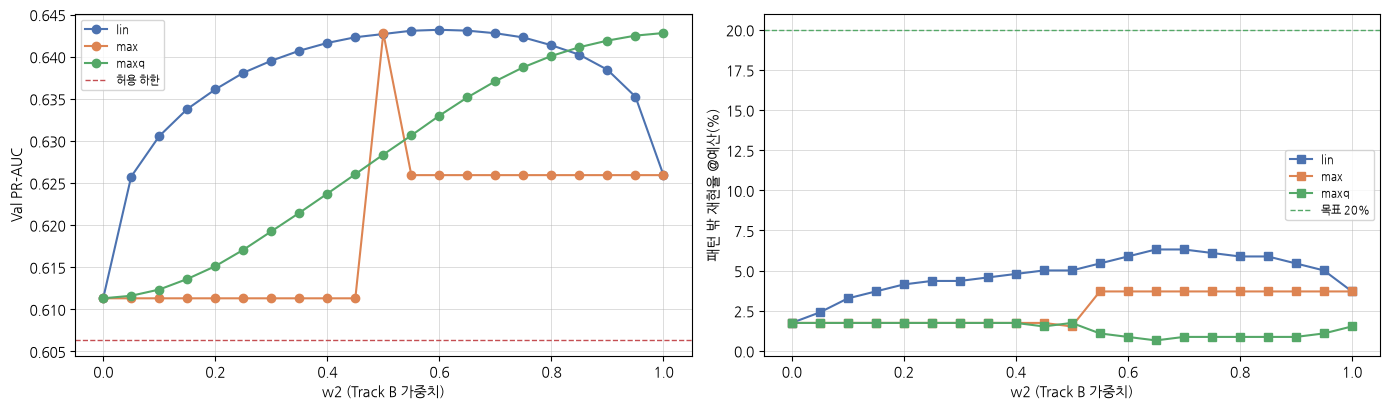

In [18]:
RG_V, RG_T = rank01(GNN_V), rank01(GNN_T)
RB_V, RB_T = rank01(TAB_V), rank01(TAB_T)

def combine(mode, w, ra, rb):
    '''세 가지 결합 계열. 전부 w=0 에서 순수 Track A 로 수렴한다.'''
    if mode == "lin":                       # 가중 순위 평균
        return (1 - w) * ra + w * rb
    if mode == "max":                       # 사양의 max(·) — 가중 스케일
        return np.maximum((1 - w) * ra, w * rb)
    # maxq: Track B 의 **상위 w 분위만** 경쟁에 참여시키는 max (경보 예산 분배형)
    #   max 계열은 순위값이 둘 다 1 에 가까운 예산 근처에서 w<0.5 이면 A 가 항상 이겨
    #   경보 집합이 변하지 않는다(실측: 21점 스윕이 3개 집합으로 붕괴). 이 형태는 그 구간에서도
    #   B 의 상위 분위를 연속적으로 밀어 넣어 해상도를 준다.
    if w <= 0:
        return ra.copy()
    return np.maximum(ra, np.clip((rb - (1.0 - w)) / w, 0.0, 1.0))


HY_ROWS = []
for mode in ("lin", "max", "maxq"):
    for w in HYBRID_W_GRID:
        cv, ct = combine(mode, w, RG_V, RB_V), combine(mode, w, RG_T, RB_T)
        r = report_row(f"{mode} w1={1-w:.2f}/w2={w:.2f}", cv, ct)
        HY_ROWS.append({"결합": mode, "w1": round(1 - w, 3), "w2": w, **{k: v for k, v in r.items() if k != "모델"}})
HY = pd.DataFrame(HY_ROWS)
HY["_sel"] = HY["val패턴밖R"].fillna(-1.0)     # val 패턴밖 양성이 0건인 경우에도 결정적으로 동작

PURE = HY[(HY["결합"] == "lin") & (HY["w2"] == 0.0)].iloc[0]
# PR-AUC 손실의 허용 하한: 순수 GNN 이 목표(0.6400)를 이미 넘으면 목표선까지만 양보하고,
# 그렇지 못하면(축소 실행 등) 순수 GNN 대비 상대 허용손실을 쓴다.
FLOOR = (TARGET_VAL_PRAUC if float(PURE["Val PR-AUC"]) >= TARGET_VAL_PRAUC
         else float(PURE["Val PR-AUC"]) - HYBRID_PRAUC_TOL)
BEST = select_by_rule(HY, FLOOR, tag="하이브리드")

print(f">>> 하이브리드 확정: 결합={BEST['결합']} w1={BEST['w1']:.2f} w2={BEST['w2']:.2f}  "
      f"(val 패턴밖 {PURE['val패턴밖R']:.1f}% → {BEST['val패턴밖R']:.1f}%, "
      f"Val PR-AUC {PURE['Val PR-AUC']:.4f} → {BEST['Val PR-AUC']:.4f})")

_view = ["결합", "w1", "w2", "Val PR-AUC", "Test PR-AUC", "패턴내R@예산", "패턴밖R@예산",
         "val패턴밖R", "F1@예산"]
print("\n── 표3-1. 하이브리드 결합 가중치 스윕 (전량) ──")
print(HY[_view].round(4).to_string(index=False))

_pick = HY.loc[HY.groupby("결합")["_sel"].idxmax()]
print("\n── 표3-2. 결합 방식별 최적점 ──")
print(_pick[_view].round(4).to_string(index=False))

HYB_V = combine(str(BEST["결합"]), float(BEST["w2"]), RG_V, RB_V)
HYB_T = combine(str(BEST["결합"]), float(BEST["w2"]), RG_T, RB_T)
ROW_H = report_row(f"v10 방식 하이브리드 ({BEST['결합']}, w1={BEST['w1']:.2f}/w2={BEST['w2']:.2f})", HYB_V, HYB_T)

# ── [v12] 예산 분리 라우팅 스윕 — score_main = 확정 하이브리드 · score_b = Track B 단독 랭크 ──
#    r=0 은 v10 단일 예산과 동일 선정(분리 이득이 없으면 select_by_rule 이 자동 기각).
DB_ROWS = []
for _r in [0.0] + DUAL_R_GRID:
    _hv = dual_budget_hits(HYB_V, RB_V, "val", r=_r)
    _ht = dual_budget_hits(HYB_T, RB_T, "test", r=_r)
    _row = report_row_hits(f"r={_r:.2f}", dual_route_score(HYB_V, RB_V, _r),
                           dual_route_score(HYB_T, RB_T, _r), _hv, _ht)
    DB_ROWS.append({"r": _r, **{k: v for k, v in _row.items() if k != "모델"}})
DB = pd.DataFrame(DB_ROWS)
R_BEST = select_by_rule(DB, FLOOR, tag="예산분리")
R_STAR = float(R_BEST["r"])
print(f">>> [v12] 예산분리 확정: r={R_STAR:.2f}  "
      f"(val 패턴밖 {DB.iloc[0]['val패턴밖R']:.1f}% → {R_BEST['val패턴밖R']:.1f}%, "
      f"Val PR-AUC {DB.iloc[0]['Val PR-AUC']:.4f} → {R_BEST['Val PR-AUC']:.4f})")
print("\n── 표3-3. [v12] 예산 분리 라우팅 r 스윕 (r=0 = v10 단일 예산 · PR-AUC 는 라우팅 순서 점수) ──")
print(DB[["r", "Val PR-AUC", "Test PR-AUC", "패턴내R@예산", "패턴밖R@예산", "val패턴내R", "val패턴밖R",
          "F1@예산"]].round(4).to_string(index=False))

HIT12_V = dual_budget_hits(HYB_V, RB_V, "val", r=R_STAR)
HIT12_T = dual_budget_hits(HYB_T, RB_T, "test", r=R_STAR)
ROW_H12 = report_row_hits(
    f"v12 예산분리 (base={BEST['결합']} w2={BEST['w2']:.2f}, r={R_STAR:.2f})",
    dual_route_score(HYB_V, RB_V, R_STAR), dual_route_score(HYB_T, RB_T, R_STAR), HIT12_V, HIT12_T)
ROW_H0 = DB_ROWS[0]                     # r=0 (분리 off) — 표4-3 ablation 행

if SHOW_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
    for mode, c in [("lin", "#4C72B0"), ("max", "#DD8452"), ("maxq", "#55A868")]:
        s = HY[HY["결합"] == mode]
        axes[0].plot(s["w2"], s["Val PR-AUC"], "o-", color=c, label=mode)
        axes[1].plot(s["w2"], s["패턴밖R@예산"], "s-", color=c, label=mode)
    axes[0].axhline(FLOOR, color="#C44E52", ls="--", lw=1, label="허용 하한")
    axes[1].axhline(TARGET_OUT_RECALL, color="#55A868", ls="--", lw=1, label="목표 20%")
    axes[0].set_xlabel("w2 (Track B 가중치)"); axes[0].set_ylabel("Val PR-AUC")
    axes[1].set_xlabel("w2 (Track B 가중치)"); axes[1].set_ylabel("패턴 밖 재현율 @예산(%)")
    for a in axes:
        a.legend(fontsize=8); a.grid(lw=0.6, alpha=0.5); a.set_axisbelow(True)
    plt.tight_layout(); plt.show()

## §10. 최종 결과표 · 목표 달성 판정 · 산출물 저장

In [19]:
FINAL_ROWS = [ROW_A, ROW_B, ROW_H, ROW_H12]
_mx = report_row("참고: 순수 max(A,B) (w1=w2=1)", np.maximum(RG_V, RB_V), np.maximum(RG_T, RB_T))
FINAL_ROWS.append(_mx)
TBL_FINAL = show(FINAL_ROWS, "표4-1. v12 구성요소 비교 (동일 분할 · 동일 예산)")

# ── 표4-2. v10·v11·v12 3버전 비교 ─────────────────────────────────────────
#    v10/v11 행은 **전체 실행(5,077,228행 · 시드[0,1]) 실측 고정값** (각 버전 노트북 출력에서 전사).
#    v12 행만 이번 실행으로 갱신된다.
_V10_REF = {"모델": "v10 하이브리드 (lin 0.65/0.35) [전체실행 실측 고정]",
            "Val PR-AUC": 0.6532, "Test PR-AUC": 0.5945, "패턴내R@예산": 88.8889,
            "패턴밖R@예산": 3.0501, "시나리오R%": 92.8962, "P@예산": 61.2205, "F1@예산": 57.6193}
_V11_REF = {"모델": "v11 하이브리드 (maxq 0.15/0.85 · oop=20 고정 · Degree 게이팅) [전체실행 실측 고정]",
            "Val PR-AUC": 0.5597, "Test PR-AUC": 0.5151, "패턴내R@예산": 79.8246,
            "패턴밖R@예산": 4.3573, "시나리오R%": 86.8852, "P@예산": 55.7087, "F1@예산": 52.4317}
_v12_row = {**{k: v for k, v in ROW_H12.items() if k in REPORT_COLS},
            "모델": f"v12 예산분리 (base={BEST['결합']} w2={BEST['w2']:.2f}, r={R_STAR:.2f}) [이번 실행]"}
TBL_VER = show([_V10_REF, _V11_REF, _v12_row], "표4-2. v10·v11·v12 3버전 비교")
if SMOKE or MAX_ROWS:
    print("⚠️ 이번 실행은 축소 실행 — v10/v11 고정 참조행(전체 실행)과 절대값 직접 비교 불가. v12 행만 갱신됨.")
print("v11 대비 v12: oop=20 고정 → {1,3,5,8} 스윕 복원 / Degree≤2 게이팅 폐기 → 예산 분리 라우팅 대체 / "
      "Track B 신규 피처(v11 structuring prox 등)는 동결·미포함")

# ── 표4-3. ablation 실측 — 신규 장치별 기여분 (§9 예산분리 r · §7-1 GACC) ──
_abl_rows = [
    {"장치": "예산분리 r", "구성": "off (r=0 · v10 단일 예산)", "Val PR-AUC": ROW_H0["Val PR-AUC"],
     "val패턴밖R": ROW_H0["val패턴밖R"], "패턴밖R@예산": ROW_H0["패턴밖R@예산"],
     "패턴내R@예산": ROW_H0["패턴내R@예산"]},
    {"장치": "예산분리 r", "구성": f"on (r={R_STAR:.2f})", "Val PR-AUC": ROW_H12["Val PR-AUC"],
     "val패턴밖R": ROW_H12["val패턴밖R"], "패턴밖R@예산": ROW_H12["패턴밖R@예산"],
     "패턴내R@예산": ROW_H12["패턴내R@예산"]},
]
for _g_ in (GACC_ROWS if "GACC_ROWS" in globals() else []):
    _abl_rows.append({"장치": "GACC(시드0)", "구성": _g_["모델"], "Val PR-AUC": _g_["Val PR-AUC"],
                      "val패턴밖R": _g_["val패턴밖R"], "패턴밖R@예산": _g_["패턴밖R@예산"],
                      "패턴내R@예산": _g_["패턴내R@예산"]})
print("\n── 표4-3. ablation 실측 (신규 장치 기여분 · 전부 이번 실행) ──")
print(pd.DataFrame(_abl_rows).round(4).to_string(index=False))

_d_out = ROW_H12["패턴밖R@예산"] - ROW_A["패턴밖R@예산"]
_d_in = ROW_H12["패턴내R@예산"] - ROW_A["패턴내R@예산"]
_d_ap = ROW_H12["Val PR-AUC"] - ROW_A["Val PR-AUC"]
GOALS = pd.DataFrame([
    {"목표": "전체 Val PR-AUC ≥ 0.6400", "값": round(ROW_H12["Val PR-AUC"], 4),
     "기준": TARGET_VAL_PRAUC, "달성": "✅" if ROW_H12["Val PR-AUC"] >= TARGET_VAL_PRAUC else "❌"},
    {"목표": "패턴 밖 재현율 ≥ 20.0%", "값": round(ROW_H12["패턴밖R@예산"], 2),
     "기준": TARGET_OUT_RECALL, "달성": "✅" if ROW_H12["패턴밖R@예산"] >= TARGET_OUT_RECALL else "❌"},
    {"목표": "패턴 내 재현율 유지 (Track A 대비)", "값": round(ROW_H12["패턴내R@예산"], 2),
     "기준": round(ROW_A["패턴내R@예산"], 2), "달성": "✅" if _d_in >= -1.0 else "❌"},
])
print("\n── 표5. 목표 달성 판정 (v12 예산분리 기준) ──")
print(GOALS.to_string(index=False))
print(f"\nTrack A → v12 변화: 패턴 밖 {_d_out:+.2f}%p / 패턴 내 {_d_in:+.2f}%p / "
      f"Val PR-AUC {_d_ap:+.4f} / Test PR-AUC {ROW_H12['Test PR-AUC']-ROW_A['Test PR-AUC']:+.4f}")

LGB_MODEL.booster_.save_model(str(ART_DIR / "lgbm_trackB.txt"))   # GNN 은 §7 에서 이미 저장
SUMMARY = {
    "version": "v12",
    "mode": "smoke" if SMOKE else "full", "rows": int(n), "device": str(DEVICE),
    "trackA_cfg": dict(HIDDEN=HIDDEN, N_LAYERS=N_LAYERS, AUX_NODE_W=AUX_NODE_W,
                       MSG_DROPOUT=MSG_DROPOUT, LOSS=f"{LOSS_TYPE}{FOCAL_GAMMA:g}", REV_W=1.0,
                       AMP=str(AMP_DTYPE).split(".")[-1], seeds=SEED_LIST, epochs=EPOCHS,
                       GACC_DIM=(GACC_DIM if USE_GACC else 0)),
    "trackB_cfg": {k: float(v) for k, v in LGB_CFG.items()},
    "trackB_oop_grid": LGB_OOP_GRID,
    "trackB_features": TAB_EXTRA,
    "hybrid": {"mode": str(BEST["결합"]), "w1": float(BEST["w1"]), "w2": float(BEST["w2"])},
    "dual_budget": {"grid": DUAL_R_GRID, "r": R_STAR, "rule": select_by_rule.last},
    "gacc_ablation_seed0": (GACC_ABL if "GACC_ABL" in globals() else None),
    "v11_disposed": {"oop20_fixed": "폐기 (Val PR-AUC 붕괴)",
                     "degree_gating": "폐기 (차수 중앙값 11 vs 12 — 변별력 없음, 예산분리로 대체)"},
    "final": {r["모델"]: {k: (None if isinstance(v, float) and not np.isfinite(v) else v)
                         for k, v in r.items() if k != "모델"} for r in FINAL_ROWS},
    "goals": GOALS.to_dict("records"),
}
(ART_DIR / "summary_v12.json").write_text(json.dumps(SUMMARY, ensure_ascii=False, indent=2),
                                          encoding="utf-8")
print(f"\n산출물 저장: {ART_DIR.resolve()} "
      f"(gnn_seed*.pt × {len(runs)}, lgbm_trackB.txt, summary_v12.json)")
print("\n[v12] 완료 — 오류 0건")


── 표4-1. v12 구성요소 비교 (동일 분할 · 동일 예산) ──
                                 모델  Val PR-AUC  Test PR-AUC  패턴내R@예산  패턴밖R@예산  시나리오R%    P@예산   F1@예산
             Track A · GNN 앙상블(2시드)      0.6113       0.5751  88.3041   1.7429 95.0820 60.2362 56.6929
           Track B · LightGBM(비그래프)      0.6259       0.5540  83.3333   3.7037 89.6175 57.7756 54.3770
v10 방식 하이브리드 (lin, w1=0.45/w2=0.55)      0.6431       0.5913  86.2573   5.4466 92.3497 60.5315 56.9708
v12 예산분리 (base=lin w2=0.55, r=0.00)      0.6431       0.5913  86.2573   5.4466 92.3497 60.5911 56.9972
          참고: 순수 max(A,B) (w1=w2=1)      0.6428       0.5951  91.0819   1.5251 96.1749 61.9469 58.3333

── 표4-2. v10·v11·v12 3버전 비교 ──
                                                              모델  Val PR-AUC  Test PR-AUC  패턴내R@예산  패턴밖R@예산  시나리오R%    P@예산   F1@예산
                          v10 하이브리드 (lin 0.65/0.35) [전체실행 실측 고정]      0.6532       0.5945  88.8889   3.0501 92.8962 61.2205 57.6193
v11 하이브리드 (maxq 0.15/0.85 · oop=20 고정 · Degre

## §11. 여전히 남은 것 (숨기지 않고 명시)

1. **패턴 밖 재현율 20% 목표의 구조적 상한** — 예산 분리는 "예산 배분" 문제만 고친다. Track B 단독의 val 패턴밖 재현율이 낮으면(v10 전체실행 실측 ~5%@전체예산) r 몫으로 잡을 수 있는 양이 그만큼 묶인다. Track B 판별력 자체의 개선(피처)은 이번 버전에서 동결 — 다음 버전 과제.
2. **§2 `order_idx` 이월** — 행 순서 기반 피처(src_seq/gap 등)의 동시각 비결정성은 v9 기준선 보존을 위해 v12 도 그대로 이월 (§2 상단 명시 참조).
3. **GACC 의 train 윈도우 내 미래 참조** — train 윈도우 노드는 자기 미래(train 구간 한정) 활동 통계를 본다. 라벨 무관·train 한정이라 val/test 평가 누수는 없으나, train 분포와 추론 시점 분포가 완전히 같지는 않다 (v9 GACC 정의 동일).
4. **예산분리 후보의 PR-AUC 는 근사** — `dual_route_score` 는 두 갈래 겹침을 보정하지 않은 순서 점수다. 재현율·P/F1 은 전부 `dual_budget_hits` 정확 mask 실측이며, PR-AUC 는 선택 규칙의 하한 제약용으로만 쓴다.
5. **GACC ablation 은 시드 0 단일 비교** — 시드 간 편차(v10 실측 시드0 0.6357 vs 시드1 0.6277)와 겹치는 크기의 기여분이면 시드 확장 재검 필요.
6. **v11 잔재의 재평가 미실시** — structuring proximity 등 v11 Track B 피처는 oop 스윕 정상화 상태에서 재평가할 가치가 있으나, 이번 버전은 구조 변경(4곳)에 집중해 동결.